# London Planning: Approval, Rejection and Decision Times for Full Applications

**Question:** How do approval and rejection rates for *full* planning applications vary across London's boroughs, and how does the time taken to reach a decision compare?

This notebook covers:
1. **Data overview and quality:** structure, missingness, anomalies
2. **Scoping and cleaning:** full applications only, with a consistent outcome definition
3. **Univariate EDA:** outcomes, decision times, application characteristics
4. **Borough comparison:** approval and rejection rates, with confidence intervals
5. **Decision times by borough:** medians, spread, share decided within the statutory period
6. **Trends over time**
7. **Correlational analysis:** at the application level and the borough level
8. **Key findings and caveats**

**Definitions used throughout**
- The `status` column is the normalised outcome. The raw `decision` text differs by borough ("Grant", "Approve with Conditions", "REFUSED"...), so it isn't used for classification.
- **Approved** = `Permitted` + `Conditions` (approved subject to conditions). **Rejected** = `Rejected`.
- **Approval rate** = approved ÷ (approved + rejected). **Rejection rate** = 1 − approval rate. Withdrawn and undecided applications are reported separately and excluded from both rates.
- **Decision time** = `days_to_decision` (decided date − start date).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import polars as pl
from scipy import stats

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

# Colours: blue = approved, red = rejected, grey = neither
APPROVED_C = "#2a78d6"
REJECTED_C = "#e34948"
NEUTRAL_C = "#a8a79f"
INK = "#0b0b0b"
INK_2 = "#52514e"
GRID = "#e4e3df"
DIVERGING = LinearSegmentedColormap.from_list("rd_gy_bu", [REJECTED_C, "#f0efec", APPROVED_C])
SEQUENTIAL = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#6da7ec", "#256abf", "#0d366b"])

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "legend.frameon": False,
    "font.size": 9.5,
})
pct = mtick.PercentFormatter(1.0, decimals=0)

## 1. Data overview and quality

In [2]:
data = pd.read_csv("data/housing.csv", low_memory=False)
print(f"{data.shape[0]:,} rows × {data.shape[1]} columns")
data.head()

181,929 rows × 27 columns


,name,area_name,reference,uid,url,description,app_type,app_size,status,decision,decided_by,start_date,decided_date,target_decision_date,days_to_decision,last_changed,fetched_at,n_comments,n_documents,n_statutory_days,n_dwellings,housing_relevance_score,lat,lng,ward_name,agent_company,case_officer
0,Barking/22/00001/HSE,Barking and Dagenham,NaN,22/00001/HSE,https://online-befirst.lbbd.gov.uk/planning/in...,"Construction of single storey front extension,...",Full,Small,Rejected,Refused,NaN,2022-01-04,2022-02-23,NaN,50.0,2026-04-04 07:44:33.927050+00:00,2026-08-08 13:56:45.467546+00:00,NaN,14.0,NaN,NaN,0.961223,51.557018,0.154785,Heath,NaN,See source
1,Barking/22/00003/HSE,Barking and Dagenham,NaN,22/00003/HSE,https://online-befirst.lbbd.gov.uk/planning/in...,Construction of a rear dormer extension includ...,Full,Small,Permitted,Approved,NaN,2022-01-03,2022-02-28,NaN,56.0,2026-04-04 07:44:33.988628+00:00,2026-08-08 13:56:45.467546+00:00,NaN,9.0,NaN,NaN,0.943544,51.547127,0.104715,Longbridge,NaN,See source
2,Barking/22/00005/CLUE,Barking and Dagenham,NaN,22/00005/CLUE,https://online-befirst.lbbd.gov.uk/planning/in...,Application for a lawful development certifica...,Amendment,Small,Rejected,Not Lawful (Certificate),NaN,2022-01-01,2022-02-28,NaN,58.0,2025-06-30 07:31:43.872963+00:00,2026-08-08 13:56:45.467546+00:00,NaN,16.0,NaN,NaN,0.947179,NaN,NaN,Gascoigne,NaN,See source
3,Barking/22/00011/HSE,Barking and Dagenham,NaN,22/00011/HSE,https://online-befirst.lbbd.gov.uk/planning/in...,Construction of a single storey front extensio...,Full,Small,Permitted,Approved,NaN,2022-01-06,2022-03-31,NaN,84.0,2026-04-04 07:44:37.118443+00:00,2026-08-08 13:56:45.467546+00:00,NaN,11.0,NaN,NaN,0.978010,51.552368,0.143934,Heath,NaN,See source
4,Barking/22/00014/HSE,Barking and Dagenham,NaN,22/00014/HSE,https://online-befirst.lbbd.gov.uk/planning/in...,Construction of First floor Rear and Side Exte...,Full,Small,Permitted,Approved,NaN,2022-01-07,2022-05-09,NaN,122.0,2026-04-11 07:46:21.646989+00:00,2026-08-08 13:56:45.467546+00:00,NaN,17.0,NaN,NaN,0.968336,51.542236,0.104562,Longbridge,NaN,See source


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 181929 entries, 0 to 181928
Data columns (total 27 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   name                     181929 non-null  str    
 1   area_name                181929 non-null  str    
 2   reference                1424 non-null    str    
 3   uid                      181929 non-null  str    
 4   url                      181929 non-null  str    
 5   description              181929 non-null  str    
 6   app_type                 180507 non-null  str    
 7   app_size                 172518 non-null  str    
 8   status                   180496 non-null  str    
 9   decision                 154252 non-null  str    
 10  decided_by               137640 non-null  str    
 11  start_date               181929 non-null  str    
 12  decided_date             160495 non-null  str    
 13  target_decision_date     127302 non-null  str    
 14  days_to_decisio

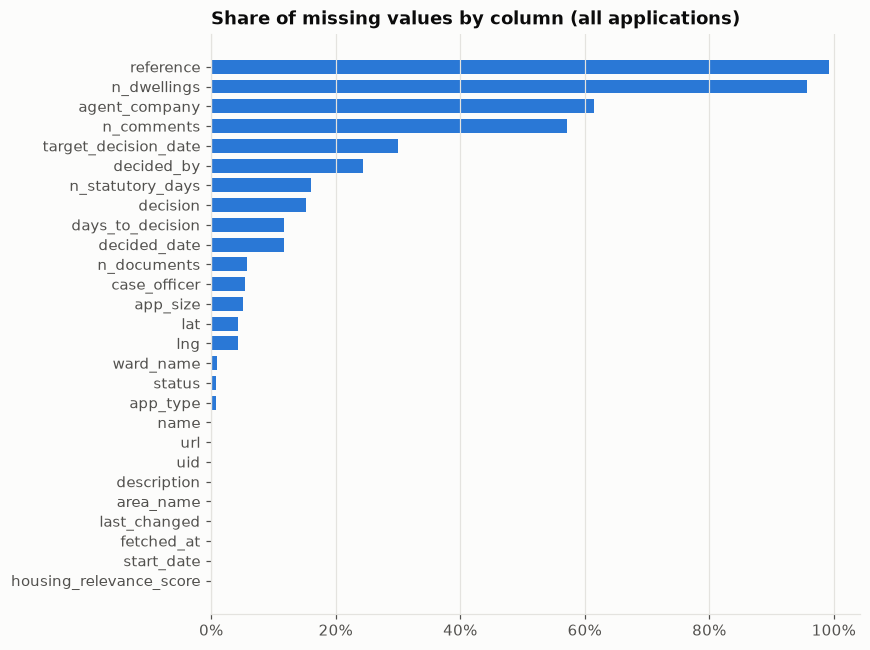

In [4]:
# Missingness across all columns
missing = data.isna().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(missing.index[::-1], missing.values[::-1], color=APPROVED_C, height=0.7)
ax.xaxis.set_major_formatter(pct)
ax.set_title("Share of missing values by column (all applications)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

`reference`, `n_dwellings`, `agent_company` and `n_comments` are mostly empty, so they only support limited analysis. The fields that matter for the question (`area_name`, `app_type`, `status`, `days_to_decision`) are well populated.

In [5]:
# Duplicates, categorical cardinality, and the date range
print("Duplicate application names:", data["name"].duplicated().sum())
print("Fully duplicated rows:      ", data.duplicated().sum())
print("\nDistinct values:")
print(data[["area_name", "app_type", "app_size", "status", "decision", "decided_by", "ward_name"]].nunique())
print("\nStart date range:  ", data["start_date"].min(), "→", data["start_date"].max())
print("Decided date range:", data["decided_date"].min(), "→", data["decided_date"].max())

Duplicate application names: 0


Fully duplicated rows:       0

Distinct values:
area_name       35
app_type         9
app_size         3
status           7
decision       452
decided_by     104
ward_name     1214
dtype: int64

Start date range:   2022-01-01 → 2025-12-31
Decided date range: 2022-01-11 → 2026-07-31


In [6]:
print(data["app_type"].value_counts(dropna=False), "\n")
print(data["status"].value_counts(dropna=False))

app_type
Full           98512
Outline        48476
Conditions     21121
Amendment      11133
NaN             1422
Heritage         823
Other            168
Trees            127
Advertising       84
Telecoms          63
Name: count, dtype: int64 

status
Permitted     97827
Conditions    34057
Rejected      31504
Undecided      9832
Withdrawn      7198
NaN            1433
Unresolved       63
Referred         15
Name: count, dtype: int64


**Planning authorities.** The data covers the 32 London boroughs plus three authorities that aren't boroughs:
- the **City of London**
- **Old Oak & Park Royal** and **London Legacy**, both Mayoral Development Corporations

All three have very few applications. They're kept in the tables, but borough rankings and borough-level correlations only include authorities with at least 100 decided full applications.

## 2. Scoping and cleaning: full applications

In [7]:
APPROVED = {"Permitted", "Conditions"}
OUTCOME_MAP = {
    "Permitted": "Approved", "Conditions": "Approved",
    "Rejected": "Rejected", "Withdrawn": "Withdrawn",
    "Undecided": "Undecided", "Unresolved": "Undecided", "Referred": "Undecided",
}

full = data[data["app_type"] == "Full"].copy()
full["outcome"] = full["status"].map(OUTCOME_MAP).fillna("Unknown")
full["start_date"] = pd.to_datetime(full["start_date"])
full["decided_date"] = pd.to_datetime(full["decided_date"])
full["start_year"] = full["start_date"].dt.year
full["start_q"] = full["start_date"].dt.to_period("Q")


def decision_route(x):
    """Collapse ~200 free-text 'decided_by' values into a decision route."""
    if pd.isna(x):
        return "Unknown"
    s = str(x).lower()
    if "committee" in s or "members" in s:
        return "Committee"
    if "deleg" in s:
        return "Delegated"
    return "Other"


full["route"] = full["decided_by"].map(decision_route)
full["size_ord"] = full["app_size"].map({"Small": 0, "Medium": 1, "Large": 2})

print(f"Full applications: {len(full):,} ({len(full) / len(data):.0%} of all rows)")
full["outcome"].value_counts().to_frame("n").assign(share=lambda d: (d.n / d.n.sum()).round(3))

Full applications: 98,512 (54% of all rows)


,n,share
outcome,,
Approved,69122,0.702
Rejected,18680,0.190
Undecided,5878,0.060
Withdrawn,3969,0.040
Unknown,863,0.009


In [8]:
# Quality checks on decision time
dec = full[full["outcome"].isin(["Approved", "Rejected"])].copy()
dec["approved"] = (dec["outcome"] == "Approved").astype(int)

recalc = (dec["decided_date"] - dec["start_date"]).dt.days
print("days_to_decision disagrees with the recalculated dates:", int((recalc != dec["days_to_decision"]).sum() - recalc.isna().sum()))
print("Decided but no decision time:", dec["days_to_decision"].isna().sum())
print("Negative decision times:     ", (dec["days_to_decision"] < 0).sum())
print("Over 2 years:                ", (dec["days_to_decision"] > 730).sum())

# Negative durations are data errors. Very long ones are real (appeals, S106 agreements) and kept;
# medians are used so they don't dominate.
dec["valid_days"] = dec["days_to_decision"].where(dec["days_to_decision"] >= 0)

# Statutory period: 8 weeks for minor/other, 13 weeks for major (≈ Large).
# Government statistics also count agreed extensions of time as "in time", so this measure is stricter.
dec["stat_days"] = np.where(dec["app_size"] == "Large", 91, 56)
dec["in_time"] = (dec["valid_days"] <= dec["stat_days"]).astype(float).where(dec["valid_days"].notna())
print(f"\nDecided full applications used for analysis: {len(dec):,}")

days_to_decision disagrees with the recalculated dates: 0
Decided but no decision time: 4391
Negative decision times:      4
Over 2 years:                 115

Decided full applications used for analysis: 87,802


## 3. Univariate EDA

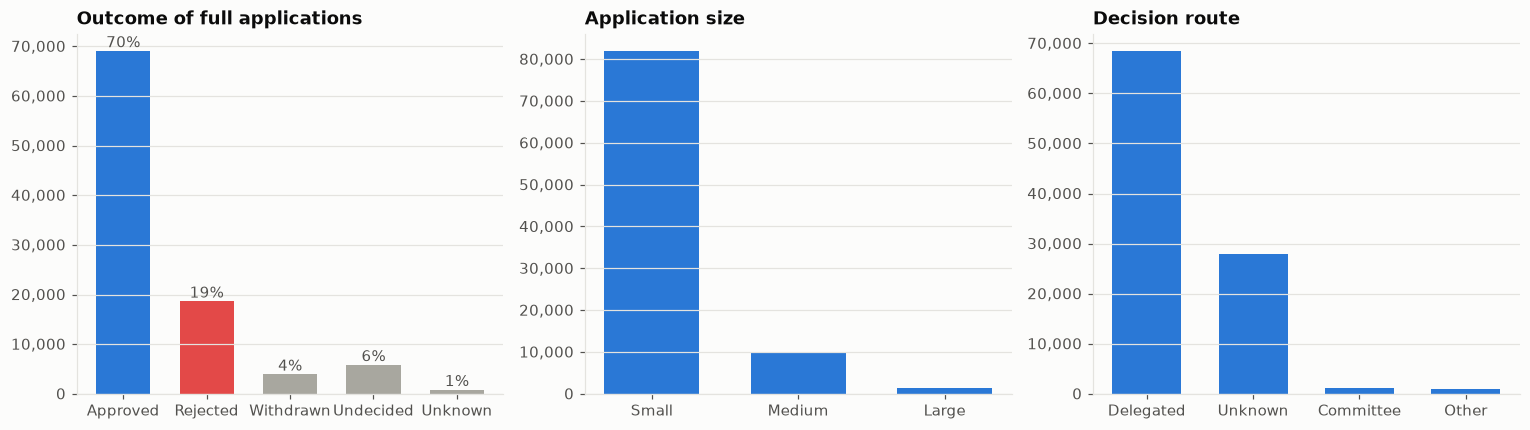

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

order = ["Approved", "Rejected", "Withdrawn", "Undecided", "Unknown"]
counts = full["outcome"].value_counts().reindex(order).fillna(0)
colors = [APPROVED_C, REJECTED_C, NEUTRAL_C, NEUTRAL_C, NEUTRAL_C]
axes[0].bar(counts.index, counts.values, color=colors, width=0.65)
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v / counts.sum():.0%}", ha="center", va="bottom", color=INK_2)
axes[0].set_title("Outcome of full applications")
axes[0].grid(axis="x", visible=False)
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

size_counts = full["app_size"].value_counts().reindex(["Small", "Medium", "Large"])
axes[1].bar(size_counts.index, size_counts.values, color=APPROVED_C, width=0.65)
axes[1].set_title("Application size")
axes[1].grid(axis="x", visible=False)
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

route_counts = full["route"].value_counts()
axes[2].bar(route_counts.index, route_counts.values, color=APPROVED_C, width=0.65)
axes[2].set_title("Decision route")
axes[2].grid(axis="x", visible=False)
axes[2].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()

count    83407.0
mean        87.0
std         73.1
min          0.0
5%          42.0
25%         56.0
50%         63.0
75%         90.0
95%        207.0
99%        413.0
max       1362.0
Name: valid_days, dtype: float64
Skewness: 5.04


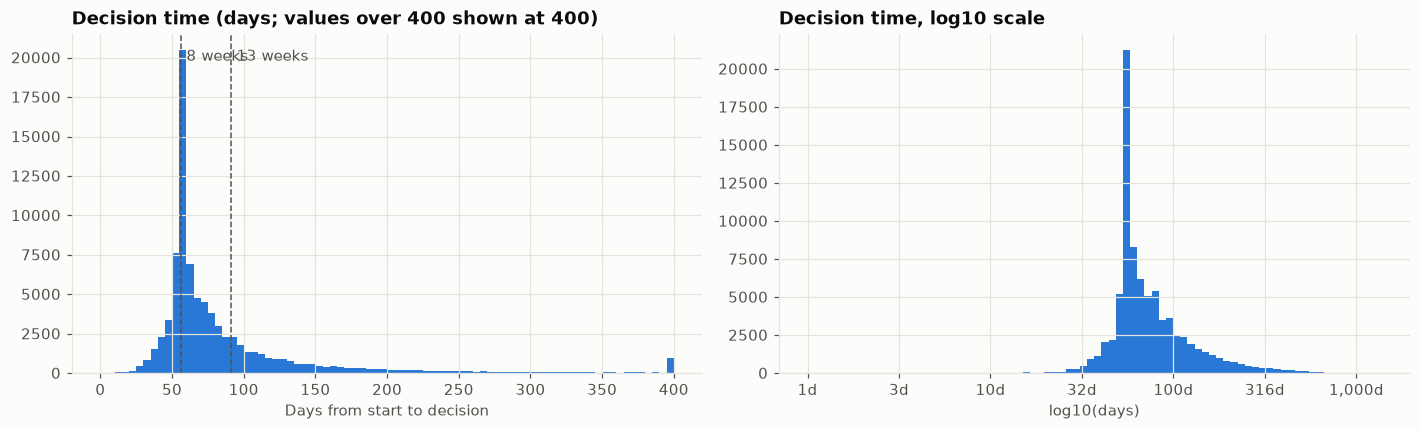

In [10]:
d = dec["valid_days"].dropna()
print(d.describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(1))
print(f"Skewness: {d.skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(d.clip(upper=400), bins=80, color=APPROVED_C)
for x, lbl in [(56, "8 weeks"), (91, "13 weeks")]:
    axes[0].axvline(x, color=INK_2, ls="--", lw=1)
    axes[0].text(x + 4, axes[0].get_ylim()[1] * 0.92, lbl, color=INK_2)
axes[0].set_title("Decision time (days; values over 400 shown at 400)")
axes[0].set_xlabel("Days from start to decision")

axes[1].hist(np.log10(d[d > 0]), bins=80, color=APPROVED_C)
axes[1].set_title("Decision time, log10 scale")
axes[1].set_xlabel("log10(days)")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{10 ** v:,.0f}d"))
plt.tight_layout()
plt.show()

Decision times are strongly right-skewed. Most full applications cluster just before the 8-week statutory deadline, and there's a long tail stretching past a year. This is why the analysis uses **medians and rank-based (Spearman / Mann-Whitney / Kruskal-Wallis) statistics** rather than means and Pearson correlations.

                           count    mean     std   min    50%    90%    99%     max
n_documents              83251.0   14.10   18.21   0.0  11.00   23.0   59.0  2047.0
n_comments               32271.0    2.16   20.74   0.0   0.00    3.0   31.3  1978.0
n_dwellings                823.0  165.22  253.21  10.0  59.00  449.0  839.0  2550.0
housing_relevance_score  87802.0    0.97    0.03   0.9   0.98    1.0    1.0     1.0


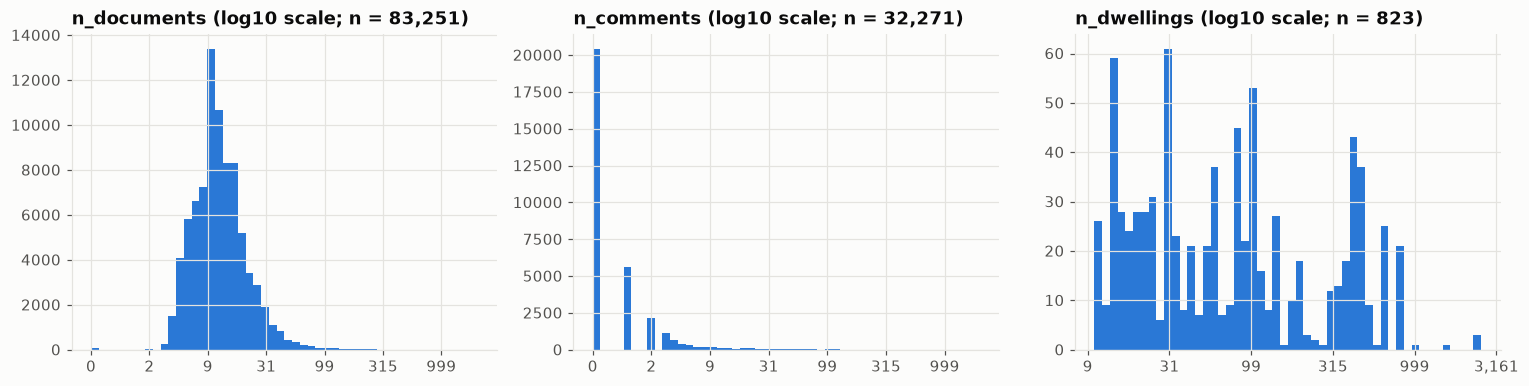

In [11]:
# Other numeric fields for decided full applications
num_cols = ["n_documents", "n_comments", "n_dwellings", "housing_relevance_score"]
print(dec[num_cols].describe(percentiles=[.5, .9, .99]).T.round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, c in zip(axes, ["n_documents", "n_comments", "n_dwellings"]):
    v = dec[c].dropna()
    ax.hist(np.log10(v + 1), bins=50, color=APPROVED_C)
    ax.set_title(f"{c} (log10 scale; n = {len(v):,})")
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{10 ** x - 1:,.0f}"))
plt.tight_layout()
plt.show()

## 4. Approval and rejection rates by borough

In [12]:
def wilson_ci(k, n, z=1.96):
    """95% Wilson score interval for a binomial proportion."""
    p = k / n
    denom = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return centre - half, centre + half


MIN_DECIDED = 100

outcome_counts = pd.crosstab(full["area_name"], full["outcome"])
borough = pd.DataFrame({
    "total_full": outcome_counts.sum(axis=1),
    "approved": outcome_counts.get("Approved", 0),
    "rejected": outcome_counts.get("Rejected", 0),
    "withdrawn": outcome_counts.get("Withdrawn", 0),
    "undecided": outcome_counts.get("Undecided", 0),
})
borough["decided"] = borough["approved"] + borough["rejected"]
borough["approval_rate"] = borough["approved"] / borough["decided"]
borough["rejection_rate"] = 1 - borough["approval_rate"]
borough["withdrawal_rate"] = borough["withdrawn"] / borough["total_full"]
borough["ci_low"], borough["ci_high"] = wilson_ci(borough["approved"], borough["decided"])
borough["reliable"] = borough["decided"] >= MIN_DECIDED
borough = borough.sort_values("approval_rate", ascending=False)

LONDON_APPROVAL = borough["approved"].sum() / borough["decided"].sum()
print(f"London-wide approval rate: {LONDON_APPROVAL:.1%}   rejection rate: {1 - LONDON_APPROVAL:.1%}")
print("Excluded from rankings (< 100 decided):", list(borough.index[~borough["reliable"]]))

(borough[["total_full", "decided", "approval_rate", "rejection_rate", "ci_low", "ci_high", "withdrawal_rate"]]
 .style.format({"approval_rate": "{:.1%}", "rejection_rate": "{:.1%}", "ci_low": "{:.1%}",
                "ci_high": "{:.1%}", "withdrawal_rate": "{:.1%}", "total_full": "{:,}", "decided": "{:,}"})
 .background_gradient(subset=["approval_rate"], cmap=SEQUENTIAL))

London-wide approval rate: 78.7%   rejection rate: 21.3%
Excluded from rankings (< 100 decided): ['City', 'London Legacy', 'Old Oak Park Royal']


,total_full,decided,approval_rate,rejection_rate,ci_low,ci_high,withdrawal_rate
area_name,,,,,,,
City,110,79,100.0%,0.0%,95.4%,100.0%,2.7%
Hammersmith and Fulham,"2,656","2,375",94.2%,5.8%,93.2%,95.1%,5.3%
Wandsworth,"5,582","5,228",93.4%,6.6%,92.7%,94.1%,4.8%
Southwark,"1,651","1,331",91.7%,8.3%,90.1%,93.0%,2.6%
London Legacy,58,47,89.4%,10.6%,77.4%,95.4%,10.3%
Camden,"1,612","1,388",87.6%,12.4%,85.8%,89.2%,9.0%
Westminster,"1,087",546,87.2%,12.8%,84.1%,89.7%,5.5%
Kensington,756,617,86.7%,13.3%,83.8%,89.2%,16.0%
Bexley,"3,933","2,685",86.7%,13.3%,85.3%,87.9%,1.0%


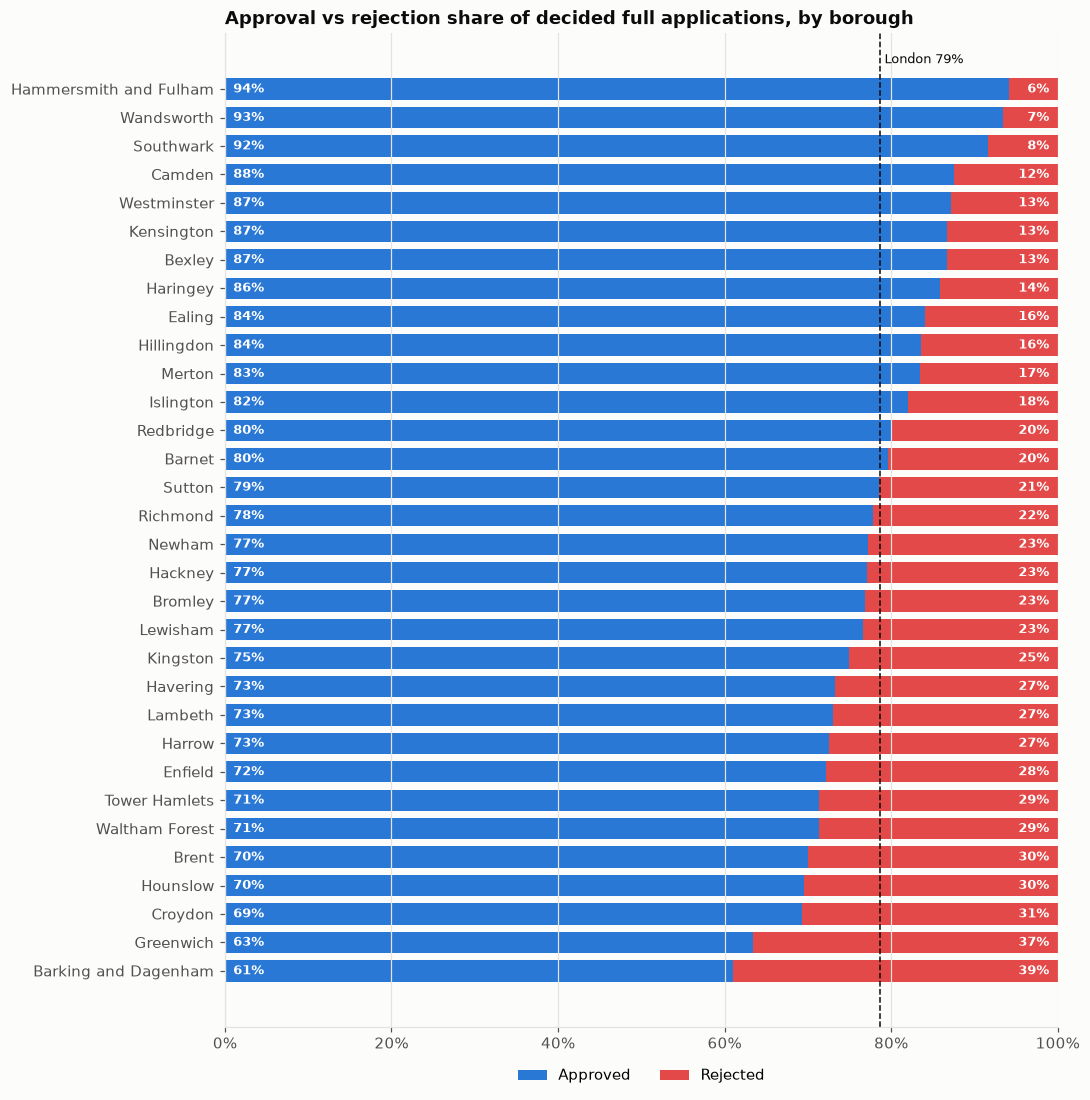

In [13]:
b = borough[borough["reliable"]].sort_values("approval_rate")
fig, ax = plt.subplots(figsize=(10, 10))
y = np.arange(len(b))
ax.barh(y, b["approval_rate"], color=APPROVED_C, height=0.75, label="Approved")
ax.barh(y, b["rejection_rate"], left=b["approval_rate"], color=REJECTED_C, height=0.75, label="Rejected")
for yi, (a, r) in enumerate(zip(b["approval_rate"], b["rejection_rate"])):
    ax.text(0.01, yi, f"{a:.0%}", va="center", color="white", fontsize=8.5, fontweight="bold")
    ax.text(0.99, yi, f"{r:.0%}", va="center", ha="right", color="white", fontsize=8.5, fontweight="bold")
ax.axvline(LONDON_APPROVAL, color=INK, lw=1, ls="--")
ax.text(LONDON_APPROVAL, len(b) - 0.2, f" London {LONDON_APPROVAL:.0%}", color=INK, va="bottom", fontsize=8.5)
ax.set_yticks(y, b.index)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(pct)
ax.grid(axis="y", visible=False)
ax.set_title("Approval vs rejection share of decided full applications, by borough")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.07), ncol=2)
plt.tight_layout()
plt.show()

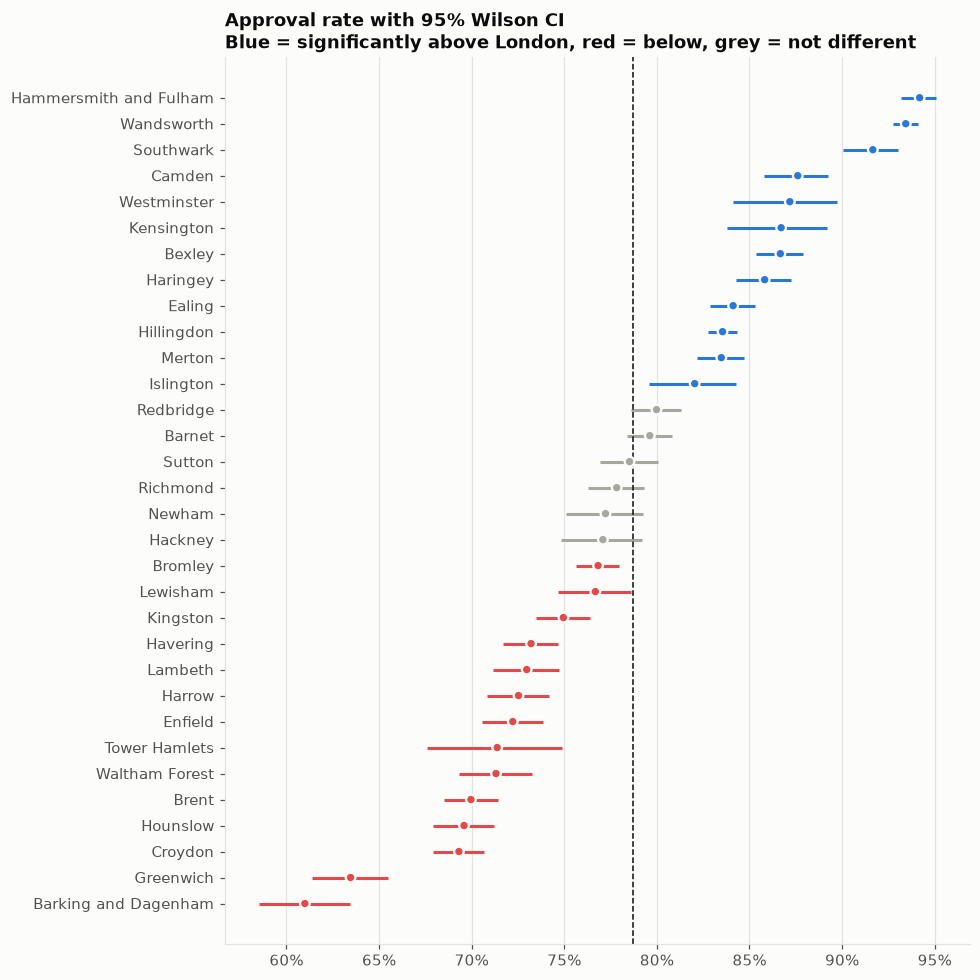

Significantly above London: 12, below: 14, not different: 6


In [14]:
# Approval rate with 95% confidence intervals: which boroughs actually differ from London?
b = borough[borough["reliable"]].sort_values("approval_rate")
fig, ax = plt.subplots(figsize=(9, 9))
y = np.arange(len(b))
sig_hi = b["ci_low"] > LONDON_APPROVAL
sig_lo = b["ci_high"] < LONDON_APPROVAL
col = np.where(sig_hi, APPROVED_C, np.where(sig_lo, REJECTED_C, NEUTRAL_C))
ax.hlines(y, b["ci_low"], b["ci_high"], color=col, lw=2)
ax.scatter(b["approval_rate"], y, color=col, s=40, zorder=3, edgecolor="#fcfcfb", linewidth=1.5)
ax.axvline(LONDON_APPROVAL, color=INK, lw=1, ls="--")
ax.set_yticks(y, b.index)
ax.xaxis.set_major_formatter(pct)
ax.grid(axis="y", visible=False)
ax.set_title("Approval rate with 95% Wilson CI\nBlue = significantly above London, red = below, grey = not different")
plt.tight_layout()
plt.show()
print(f"Significantly above London: {sig_hi.sum()}, below: {sig_lo.sum()}, not different: {(~sig_hi & ~sig_lo).sum()}")

In [15]:
# Does approval depend on application size, and is the borough ranking just a mix effect?
size_rates = (dec.groupby("app_size")["approved"].agg(["mean", "size"])
              .reindex(["Small", "Medium", "Large"]).rename(columns={"mean": "approval_rate", "size": "n"}))
print(size_rates.round(3))

small_only = dec[dec["app_size"] == "Small"].groupby("area_name")["approved"].mean()
comp = borough.loc[borough["reliable"], ["approval_rate"]].join(small_only.rename("approval_small_only"))
rho, p = stats.spearmanr(comp["approval_rate"], comp["approval_small_only"])
print(f"\nBorough ranking, all sizes vs Small-only: Spearman ρ = {rho:.2f} (p = {p:.1e})")

          approval_rate      n
app_size                      
Small             0.780  73389
Medium            0.869   9259
Large             0.891    929



Borough ranking, all sizes vs Small-only: Spearman ρ = 0.96 (p = 2.2e-18)


If the ranking holds up when only **Small** applications are counted, the borough differences aren't just caused by some boroughs receiving more large schemes.

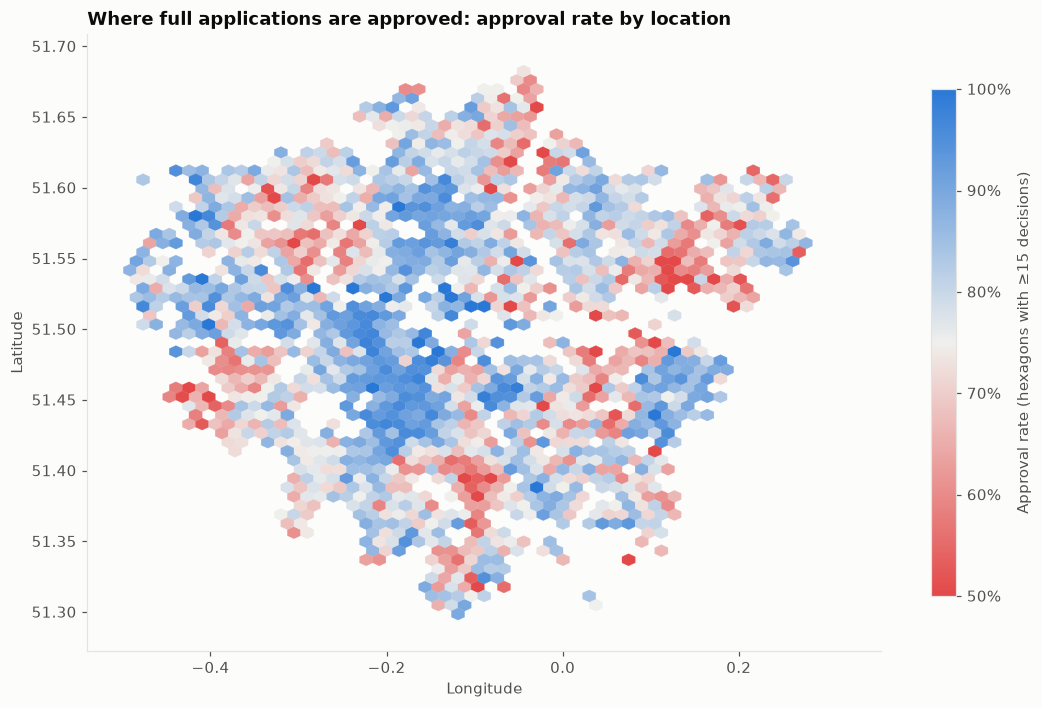

In [16]:
# Geographic view: mean approval rate per hexagon (London bounding box)
geo = dec[dec["lat"].between(51.28, 51.70) & dec["lng"].between(-0.52, 0.34)]
fig, ax = plt.subplots(figsize=(10, 7))
hb = ax.hexbin(geo["lng"], geo["lat"], C=geo["approved"], reduce_C_function=np.mean,
               gridsize=55, cmap=DIVERGING, vmin=0.5, vmax=1.0, mincnt=15, linewidths=0.2)
cb = fig.colorbar(hb, ax=ax, shrink=0.7, format=pct)
cb.set_label("Approval rate (hexagons with ≥15 decisions)")
ax.set_aspect(1 / np.cos(np.radians(51.5)))
ax.set_title("Where full applications are approved: approval rate by location")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(False)
plt.tight_layout()
plt.show()

## 5. Time to reach a decision, by borough

In [17]:
valid = dec[dec["valid_days"].notna()]
time_b = valid.groupby("area_name").agg(
    n=("valid_days", "size"),
    median_days=("valid_days", "median"),
    q1=("valid_days", lambda s: s.quantile(.25)),
    q3=("valid_days", lambda s: s.quantile(.75)),
    p90=("valid_days", lambda s: s.quantile(.90)),
    mean_days=("valid_days", "mean"),
    in_time=("in_time", "mean"),
)
time_b["iqr"] = time_b["q3"] - time_b["q1"]
med_by_outcome = valid.pivot_table(index="area_name", columns="outcome", values="valid_days", aggfunc="median")
time_b["median_approved"] = med_by_outcome["Approved"]
time_b["median_rejected"] = med_by_outcome["Rejected"]
borough = borough.join(time_b.drop(columns="n"))

LONDON_MEDIAN = valid["valid_days"].median()
LONDON_IN_TIME = valid["in_time"].mean()
print(f"London median decision time: {LONDON_MEDIAN:.0f} days; decided within statutory period: {LONDON_IN_TIME:.1%}")

(borough.loc[borough["reliable"], ["median_days", "q1", "q3", "p90", "mean_days", "in_time", "median_approved", "median_rejected"]]
 .sort_values("median_days")
 .style.format("{:.0f}").format({"in_time": "{:.1%}"})
 .background_gradient(subset=["median_days"], cmap=SEQUENTIAL))

London median decision time: 63 days; decided within statutory period: 38.3%


,median_days,q1,q3,p90,mean_days,in_time,median_approved,median_rejected
area_name,,,,,,,,
Barking and Dagenham,51.000000,45.000000,55.000000,70.000000,54.529412,79.4%,51.000000,52.000000
Redbridge,56.000000,46.000000,76.000000,110.400000,69.220870,50.7%,56.000000,63.000000
Newham,56.000000,53.000000,69.000000,103.000000,71.279924,61.1%,56.000000,56.000000
Hillingdon,56.000000,52.000000,77.000000,121.000000,73.938002,54.6%,56.000000,57.000000
Tower Hamlets,56.000000,54.000000,90.000000,188.800000,95.296422,58.1%,56.000000,56.000000
Bexley,57.000000,55.000000,71.000000,105.000000,71.922533,49.5%,56.000000,60.500000
Barnet,58.000000,56.000000,82.000000,140.000000,83.964432,41.8%,58.000000,58.000000
Haringey,58.000000,56.000000,92.000000,154.000000,88.239090,47.7%,59.000000,56.000000
Southwark,59.000000,50.000000,78.500000,120.000000,78.371150,44.5%,58.000000,70.000000


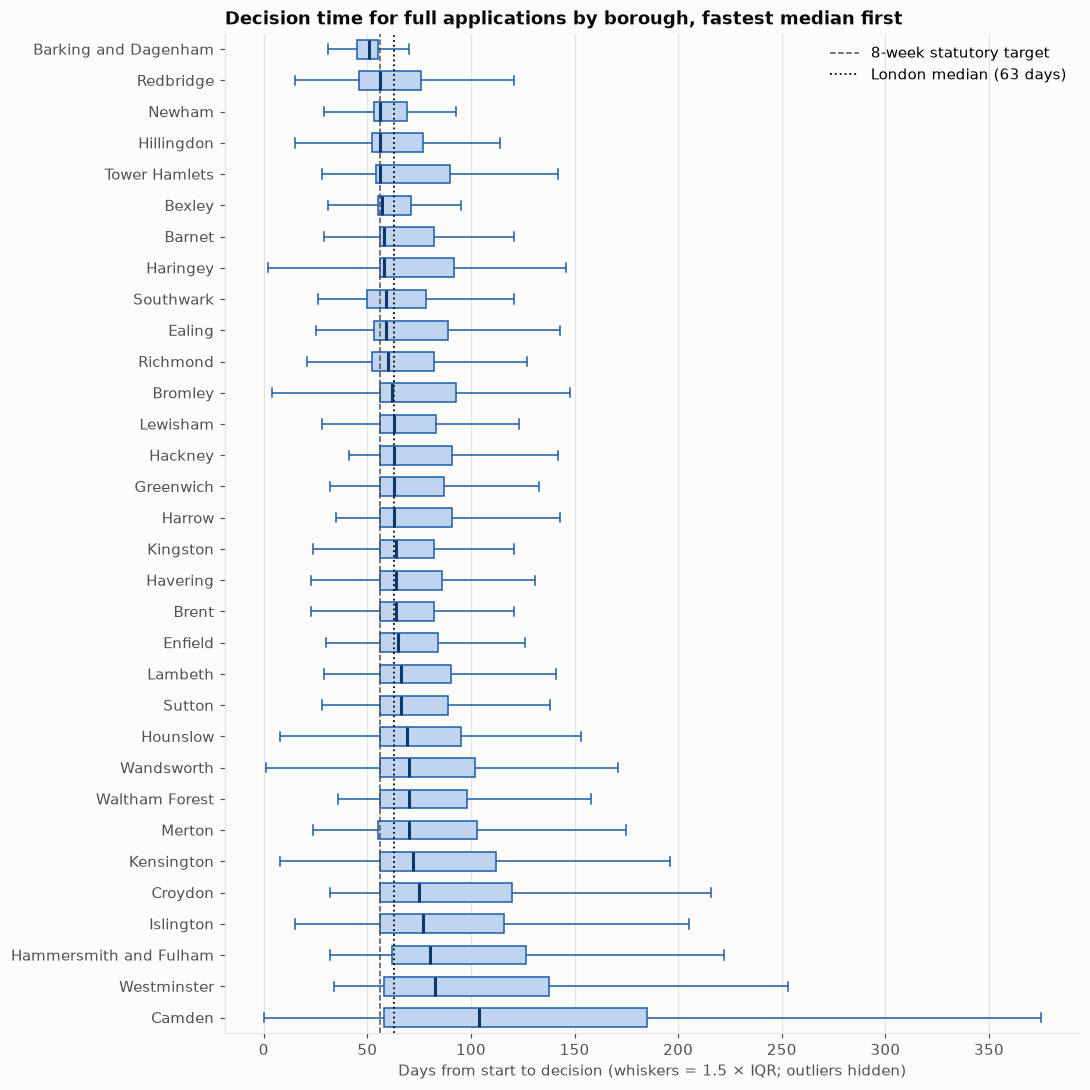

In [18]:
rel = borough.index[borough["reliable"]]
order_b = time_b.loc[rel].sort_values("median_days").index
plot_df = valid[valid["area_name"].isin(rel)]

fig, ax = plt.subplots(figsize=(10, 10))
sns.boxplot(data=plot_df, y="area_name", x="valid_days", order=order_b, showfliers=False,
            color="#b7d3f6", linecolor="#1c5cab", linewidth=1, width=0.6, ax=ax,
            medianprops={"color": "#0d366b", "linewidth": 2})
ax.axvline(56, color=INK_2, ls="--", lw=1, label="8-week statutory target")
ax.axvline(LONDON_MEDIAN, color=INK, ls=":", lw=1.2, label=f"London median ({LONDON_MEDIAN:.0f} days)")
ax.legend(loc="upper right")
ax.set_xlabel("Days from start to decision (whiskers = 1.5 × IQR; outliers hidden)")
ax.set_ylabel("")
ax.set_title("Decision time for full applications by borough, fastest median first")
plt.tight_layout()
plt.show()

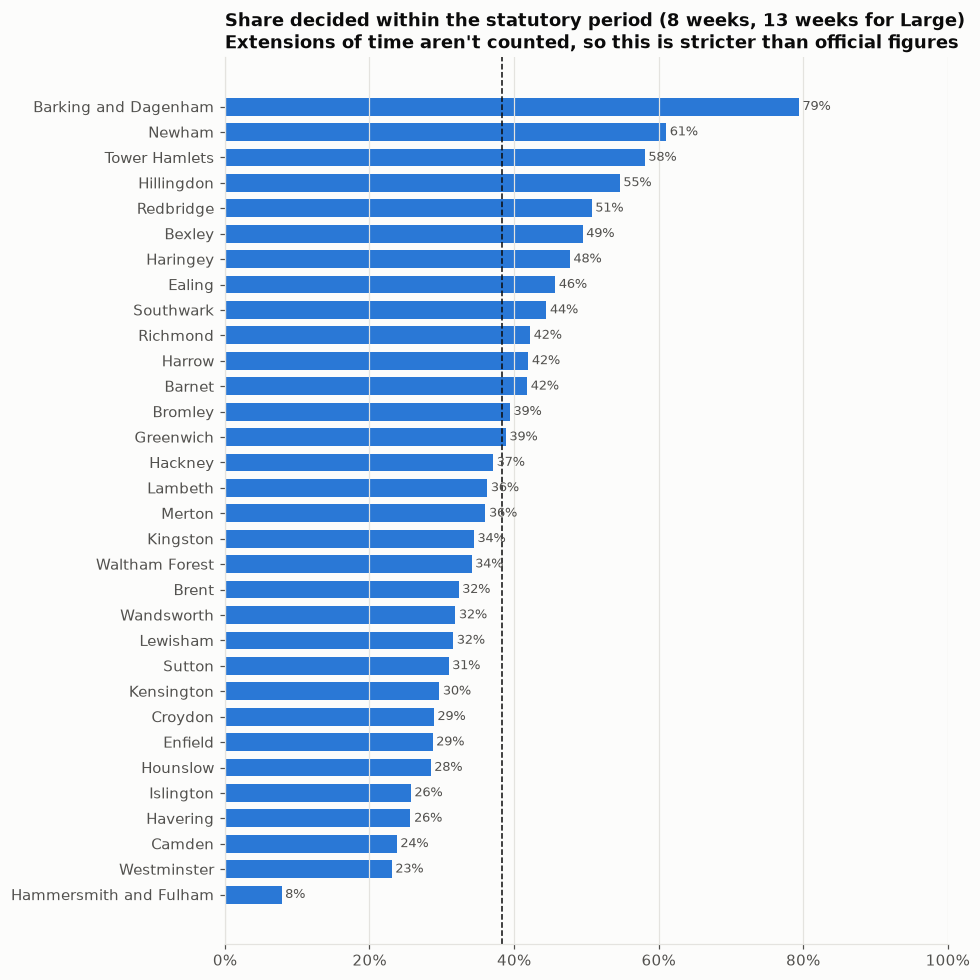

In [19]:
b = borough[borough["reliable"]].sort_values("in_time")
fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(b.index, b["in_time"], color=APPROVED_C, height=0.7)
for yi, v in enumerate(b["in_time"]):
    ax.text(v + 0.005, yi, f"{v:.0%}", va="center", color=INK_2, fontsize=8.5)
ax.axvline(LONDON_IN_TIME, color=INK, ls="--", lw=1)
ax.xaxis.set_major_formatter(pct)
ax.set_xlim(0, 1)
ax.grid(axis="y", visible=False)
ax.set_title("Share decided within the statutory period (8 weeks, 13 weeks for Large)\nExtensions of time aren't counted, so this is stricter than official figures")
plt.tight_layout()
plt.show()

Median days: approved 63, rejected 64
Mann-Whitney U p = 2.29e-31, rank-biserial r = 0.057 (positive → rejected take longer)


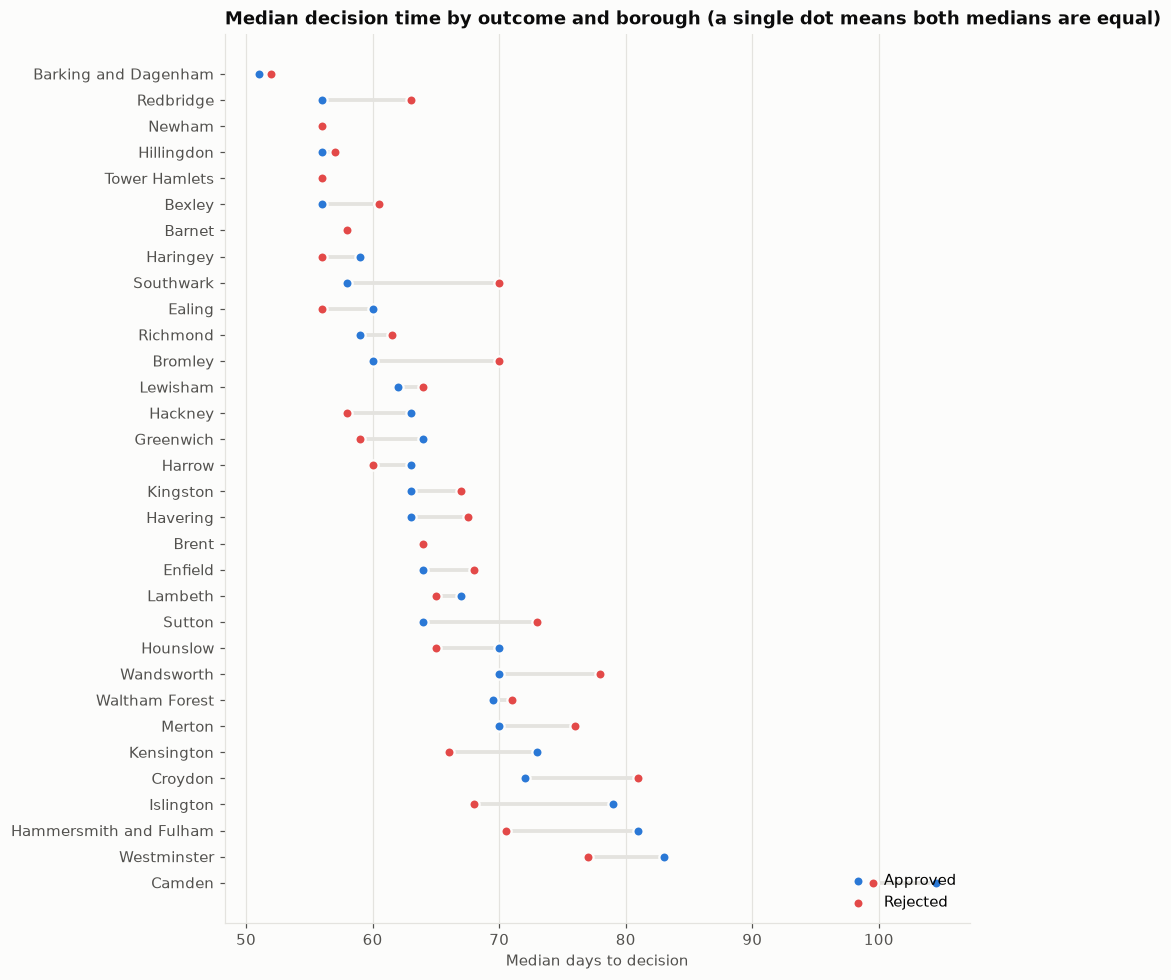

In [20]:
# Are refusals decided faster or slower than approvals?
a_days = valid.loc[valid["outcome"] == "Approved", "valid_days"]
r_days = valid.loc[valid["outcome"] == "Rejected", "valid_days"]
U, p = stats.mannwhitneyu(a_days, r_days, alternative="two-sided")
rank_biserial = 1 - 2 * U / (len(a_days) * len(r_days))
print(f"Median days: approved {a_days.median():.0f}, rejected {r_days.median():.0f}")
print(f"Mann-Whitney U p = {p:.2e}, rank-biserial r = {rank_biserial:.3f} (positive → rejected take longer)")

b = borough[borough["reliable"]].sort_values("median_days")
fig, ax = plt.subplots(figsize=(9, 9))
y = np.arange(len(b))
ax.hlines(y, b["median_approved"], b["median_rejected"], color=GRID, lw=2.5)
ax.scatter(b["median_approved"], y, color=APPROVED_C, s=45, zorder=3, label="Approved", edgecolor="#fcfcfb", linewidth=1.5)
ax.scatter(b["median_rejected"], y, color=REJECTED_C, s=45, zorder=3, label="Rejected", edgecolor="#fcfcfb", linewidth=1.5)
ax.set_yticks(y, b.index)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Median days to decision")
ax.invert_yaxis()  # fastest first, matching the box plot
ax.set_title("Median decision time by outcome and borough (a single dot means both medians are equal)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [21]:
# Decision time by size and route
print(valid.groupby("app_size")["valid_days"].describe(percentiles=[.5]).round(0).reindex(["Small", "Medium", "Large"]))
print(valid.groupby("route")["valid_days"].describe(percentiles=[.5]).round(0))

            count   mean    std  min    50%     max
app_size                                           
Small     73222.0   80.0   61.0  0.0   60.0  1194.0
Medium     9248.0  125.0   99.0  0.0   92.0  1344.0
Large       921.0  236.0  213.0  4.0  171.0  1362.0
             count   mean    std   min    50%     max
route                                                
Committee   1063.0  255.0  187.0  28.0  204.0  1362.0
Delegated  64509.0   85.0   65.0   0.0   63.0  1194.0
Other        254.0  143.0  146.0  28.0   96.0  1078.0
Unknown    17581.0   85.0   74.0   0.0   61.0  1344.0


## 6. Trends over time

The dataset only contains applications **started** from 2022 onwards, so results are grouped by start quarter (cohort). Recent cohorts are *right-censored*: slow applications that are still undecided are missing, which makes recent cohorts look faster than they really are. Shaded quarters have more than 10% of applications still undecided.

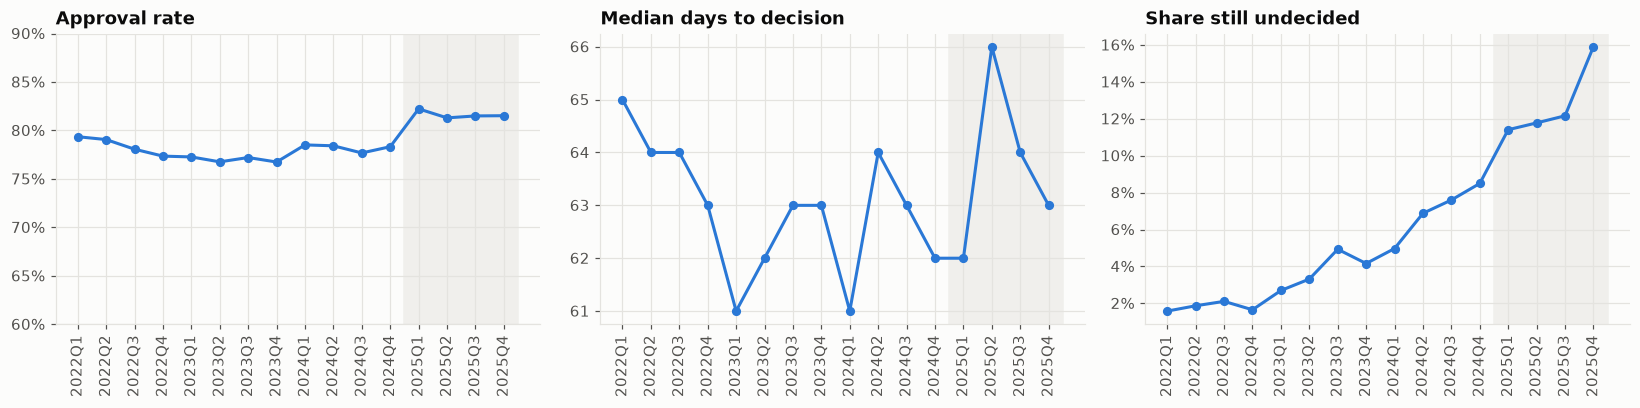

,n,undecided,approval_rate,median_days,in_time
start_q,,,,,
2022Q1,7845,0.016,0.794,65.0,0.369
2022Q2,7600,0.019,0.791,64.0,0.364
2022Q3,6738,0.021,0.781,64.0,0.366
2022Q4,6298,0.017,0.774,63.0,0.382
2023Q1,6712,0.027,0.773,61.0,0.399
2023Q2,6366,0.033,0.768,62.0,0.410
2023Q3,5923,0.049,0.772,63.0,0.401
2023Q4,5771,0.042,0.767,63.0,0.384
2024Q1,5836,0.050,0.785,61.0,0.412


In [22]:
cohort = full.groupby("start_q").agg(n=("outcome", "size"), undecided=("outcome", lambda s: (s == "Undecided").mean()))
cohort = cohort.join(dec.groupby("start_q").agg(approval_rate=("approved", "mean"),
                                                median_days=("valid_days", "median"),
                                                in_time=("in_time", "mean")))
x = cohort.index.astype(str)
censored = cohort["undecided"] > 0.10

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharex=True)
for ax, col_, title, fmt in [
    (axes[0], "approval_rate", "Approval rate", pct),
    (axes[1], "median_days", "Median days to decision", None),
    (axes[2], "undecided", "Share still undecided", pct),
]:
    ax.plot(x, cohort[col_], color=APPROVED_C, lw=2, marker="o", ms=5)
    for xi in np.where(censored)[0]:
        ax.axvspan(xi - 0.5, xi + 0.5, color="#f0efec", zorder=0)
    ax.set_title(title)
    if fmt:
        ax.yaxis.set_major_formatter(fmt)
    ax.tick_params(axis="x", rotation=90)
axes[0].set_ylim(0.6, 0.9)
plt.tight_layout()
plt.show()
cohort.round(3)

## 7. Correlational analysis

### 7a. Application level: numeric and binary variables (Spearman)
The unit here is one decided full application. Spearman's ρ is used because the variables are skewed or ordinal. `approved`, `committee` and `size_ord` are binary or ordinal codes, so ρ against them is a rank-based measure of association. Correlations are computed pairwise, so each pair uses the rows where both values exist (`n_dwellings` and `n_comments` are sparse).

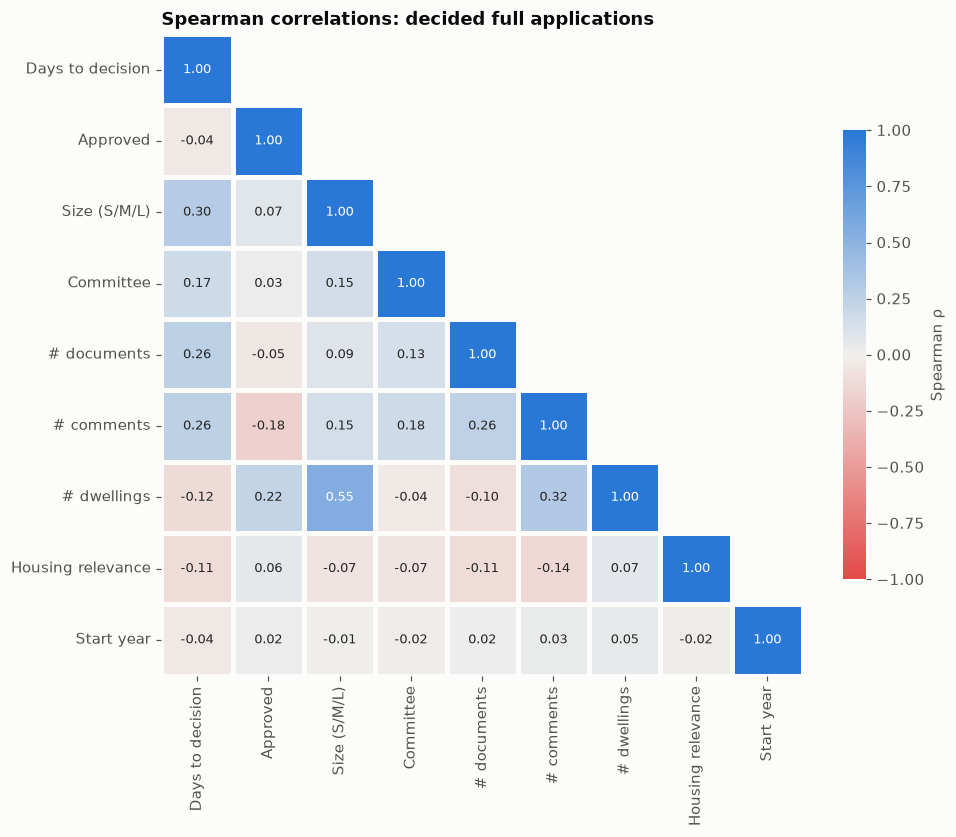

In [23]:
app = dec.assign(
    committee=(dec["route"] == "Committee").astype(float).where(dec["route"] != "Unknown"),
    start_year=dec["start_year"].astype(float),
)
corr_vars = ["valid_days", "approved", "size_ord", "committee", "n_documents", "n_comments",
             "n_dwellings", "housing_relevance_score", "start_year"]
labels = ["Days to decision", "Approved", "Size (S/M/L)", "Committee", "# documents", "# comments",
          "# dwellings", "Housing relevance", "Start year"]

rho = app[corr_vars].corr(method="spearman")
nobs = app[corr_vars].notna().astype(int).T @ app[corr_vars].notna().astype(int)

mask = np.triu(np.ones_like(rho, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(rho, mask=mask, cmap=DIVERGING, vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8.5}, linewidths=2, linecolor="#fcfcfb", square=True,
            xticklabels=labels, yticklabels=labels, cbar_kws={"shrink": 0.7, "label": "Spearman ρ"}, ax=ax)
ax.grid(False)
ax.set_title("Spearman correlations: decided full applications")
plt.tight_layout()
plt.show()

In [24]:
# Correlations with the two targets, including p-values and n
def spearman_table(df, target, others):
    rows = []
    for c in others:
        sub = df[[target, c]].dropna()
        r, p = stats.spearmanr(sub[target], sub[c])
        rows.append({"variable": c, "rho": r, "p_value": p, "n": len(sub)})
    return pd.DataFrame(rows).set_index("variable").sort_values("rho", key=abs, ascending=False)

print("Association with DAYS TO DECISION")
print(spearman_table(app, "valid_days", [v for v in corr_vars if v != "valid_days"]).round(4), "\n")
print("Association with APPROVED (1) vs REJECTED (0)")
print(spearman_table(app, "approved", [v for v in corr_vars if v != "approved"]).round(4))

Association with DAYS TO DECISION
                            rho  p_value      n
variable                                       
size_ord                 0.2954   0.0000  83391
n_comments               0.2643   0.0000  32269
n_documents              0.2586   0.0000  83072
committee                0.1744   0.0000  65826
n_dwellings             -0.1246   0.0004    812
housing_relevance_score -0.1147   0.0000  83407
start_year              -0.0413   0.0000  83407
approved                -0.0403   0.0000  83407 

Association with APPROVED (1) vs REJECTED (0)


                            rho  p_value      n
variable                                       
n_dwellings              0.2217      0.0    823
n_comments              -0.1810      0.0  32271
size_ord                 0.0736      0.0  83577
housing_relevance_score  0.0604      0.0  87802
n_documents             -0.0527      0.0  83251
valid_days              -0.0403      0.0  83407
committee                0.0253      0.0  65874
start_year               0.0241      0.0  87802


With around 80,000 observations almost every correlation is "statistically significant", so **judge them by size**. As a rough guide, |ρ| < 0.1 is negligible, 0.1–0.3 weak, 0.3–0.5 moderate and above 0.5 strong.

### 7b. Categorical associations with the outcome (χ² and Cramér's V) and with decision time (Kruskal-Wallis, ε²)

In [25]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    # Bias-corrected Cramér's V (Bergsma 2013)
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    rc, kc = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2 / min(kc - 1, rc - 1)), chi2, p, dof


def kruskal_eps2(df, group, value):
    groups = [g[value].dropna().values for _, g in df.groupby(group) if g[value].notna().sum() > 0]
    H, p = stats.kruskal(*groups)
    n = sum(len(g) for g in groups)
    return (H - len(groups) + 1) / (n - len(groups)), H, p


cat_rows = []
dec_rel = dec[dec["area_name"].isin(rel)]
for name, col_ in [("Borough", "area_name"), ("Application size", "app_size"),
                   ("Decision route", "route"), ("Start year", "start_year")]:
    sub = dec_rel[[col_, "approved", "valid_days"]].dropna(subset=[col_])
    v, chi2, p, dof = cramers_v(sub[col_], sub["approved"])
    eps2, H, pk = kruskal_eps2(sub, col_, "valid_days")
    cat_rows.append({"factor": name, "Cramér's V (vs outcome)": v, "χ² p": p,
                     "ε² (vs days)": eps2, "Kruskal p": pk, "levels": sub[col_].nunique()})
pd.DataFrame(cat_rows).set_index("factor").round(4)

,Cramér's V (vs outcome),χ² p,ε² (vs days),Kruskal p,levels
factor,,,,,
Borough,0.1892,0.0,0.0650,0.0,32
Application size,0.0732,0.0,0.0864,0.0,3
Decision route,0.0225,0.0,0.0252,0.0,4
Start year,0.0395,0.0,0.0029,0.0,4


In [26]:
# Approval rate and median time by decision route: are committee decisions different?
route_tbl = dec.groupby("route").agg(n=("approved", "size"), approval_rate=("approved", "mean"),
                                     median_days=("valid_days", "median"))
route_tbl.style.format({"n": "{:,}", "approval_rate": "{:.1%}", "median_days": "{:.0f}"})

,n,approval_rate,median_days
route,,,
Committee,"1,064",86.7%,204
Delegated,"64,555",78.4%,63
Other,255,75.3%,96
Unknown,"21,928",79.3%,61


### 7c. Borough level: do faster boroughs approve more?
Here the unit is a borough (n ≈ 32), so power is limited and p-values matter more. For each borough the variables are its approval rate, speed, workload and application mix.

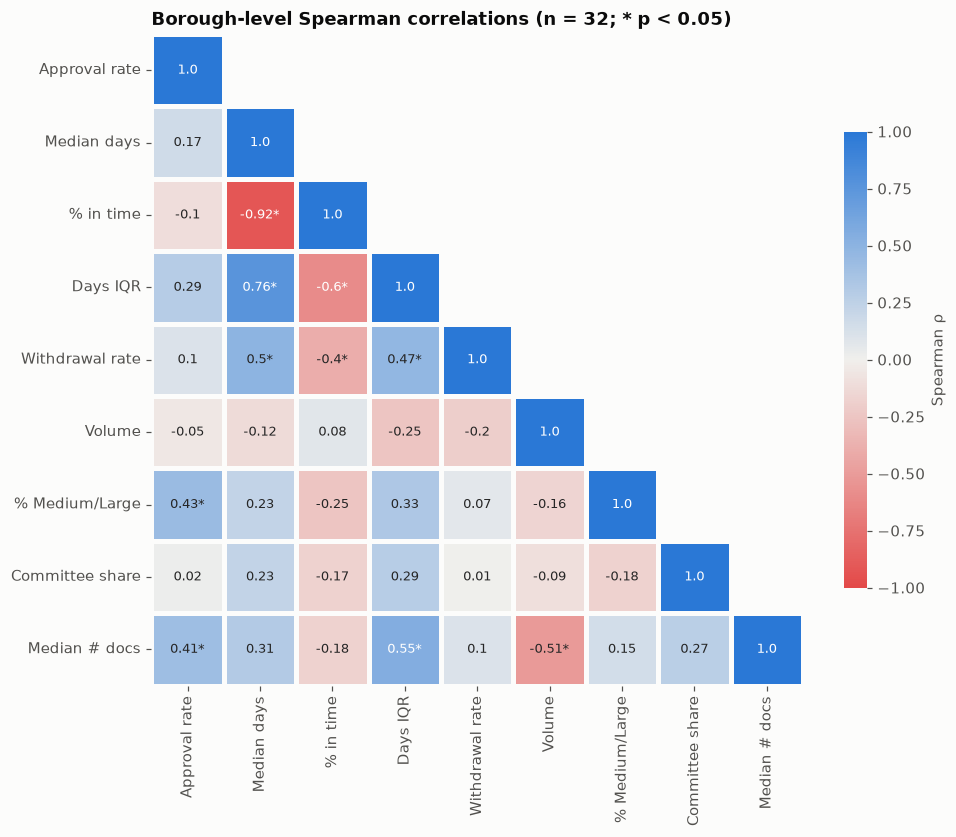

In [27]:
mix = dec.groupby("area_name").agg(
    share_medium_large=("size_ord", lambda s: (s >= 1).mean()),
    committee_share=("route", lambda s: (s == "Committee").mean()),
    median_documents=("n_documents", "median"),
)
bl = borough.loc[borough["reliable"]].join(mix)
bl["volume"] = bl["total_full"]
bvars = ["approval_rate", "median_days", "in_time", "iqr", "withdrawal_rate", "volume",
         "share_medium_large", "committee_share", "median_documents"]
blabels = ["Approval rate", "Median days", "% in time", "Days IQR", "Withdrawal rate", "Volume",
           "% Medium/Large", "Committee share", "Median # docs"]

brho = bl[bvars].corr(method="spearman")
bp = pd.DataFrame(np.ones_like(brho), index=bvars, columns=bvars)
for i in bvars:
    for j in bvars:
        if i != j:
            pair = bl[[i, j]].dropna()
            bp.loc[i, j] = stats.spearmanr(pair[i], pair[j]).pvalue
annot = brho.round(2).astype(str) + np.where(bp < 0.05, "*", "")

mask = np.triu(np.ones_like(brho, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(brho, mask=mask, cmap=DIVERGING, vmin=-1, vmax=1, center=0, annot=annot, fmt="",
            annot_kws={"size": 8.5}, linewidths=2, linecolor="#fcfcfb", square=True,
            xticklabels=blabels, yticklabels=blabels, cbar_kws={"shrink": 0.7, "label": "Spearman ρ"}, ax=ax)
ax.grid(False)
ax.set_title(f"Borough-level Spearman correlations (n = {len(bl)}; * p < 0.05)")
plt.tight_layout()
plt.show()

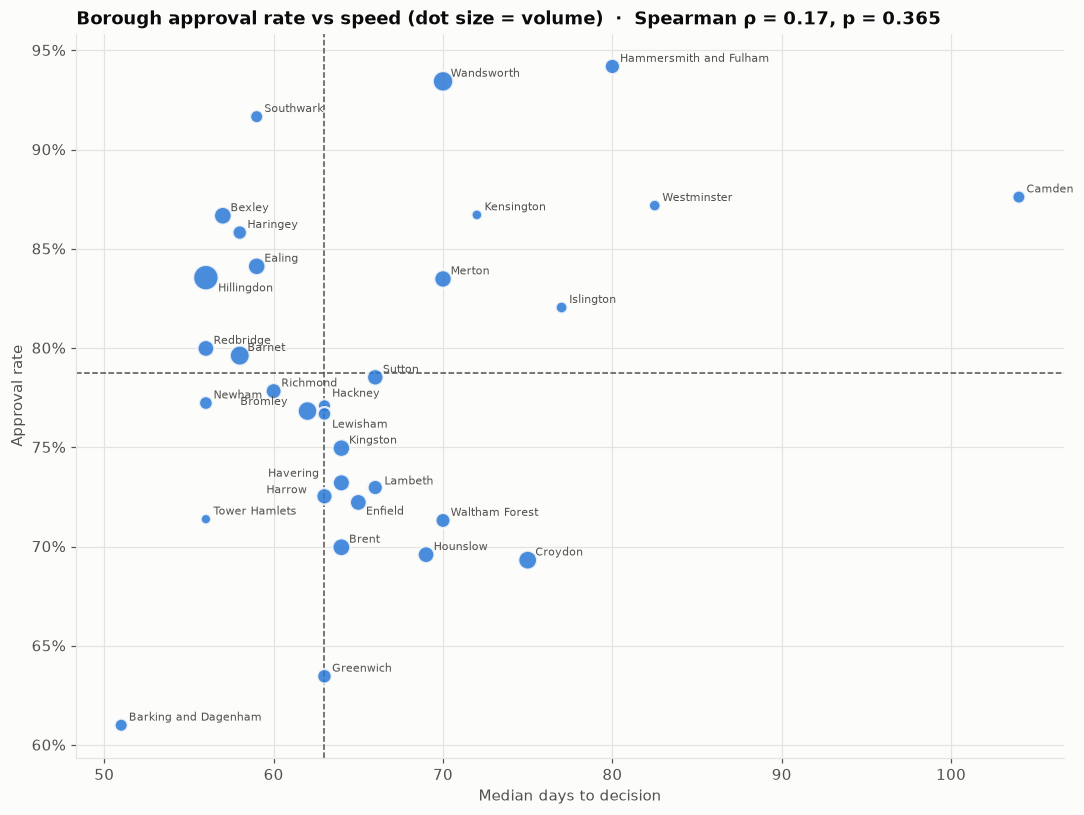

In [28]:
r, p = stats.spearmanr(bl["median_days"], bl["approval_rate"])
fig, ax = plt.subplots(figsize=(10, 7.5))
sizes = 30 + 250 * bl["volume"] / bl["volume"].max()
ax.scatter(bl["median_days"], bl["approval_rate"], s=sizes, color=APPROVED_C, alpha=0.85,
           edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
nudge = {"Hackney": (5, 6), "Lewisham": (5, -9), "Bromley": (-44, 4), "Harrow": (-38, 2),
         "Enfield": (5, -8), "Havering": (-48, 4), "Lambeth": (6, 2), "Hillingdon": (8, -9)}
for name, row in bl.iterrows():
    ax.annotate(name, (row["median_days"], row["approval_rate"]), xytext=nudge.get(name, (5, 3)),
                textcoords="offset points", fontsize=7.5, color=INK_2)
ax.axhline(LONDON_APPROVAL, color=INK_2, ls="--", lw=1)
ax.axvline(LONDON_MEDIAN, color=INK_2, ls="--", lw=1)
ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("Median days to decision")
ax.set_ylabel("Approval rate")
ax.set_title(f"Borough approval rate vs speed (dot size = volume)  ·  Spearman ρ = {r:.2f}, p = {p:.3f}")
plt.tight_layout()
plt.show()

## 8. Key findings

The cell below recomputes the headline numbers. The interpretation after it was written from this run of the data; if the data is refreshed, check the text against the printed numbers.

In [29]:
b = borough[borough["reliable"]]
top = b["approval_rate"].nlargest(3)
bot = b["approval_rate"].nsmallest(3)
fast = b["median_days"].nsmallest(3)
slow = b["median_days"].nlargest(3)
r_speed, p_speed = stats.spearmanr(b["median_days"], b["approval_rate"])

print(f"""KEY NUMBERS: full planning applications, London, started 2022–2025
- {len(full):,} full applications; {len(dec):,} decided (approved or rejected).
- London-wide: {LONDON_APPROVAL:.1%} approved, {1 - LONDON_APPROVAL:.1%} rejected.
- Borough approval range: {b['approval_rate'].min():.1%} to {b['approval_rate'].max():.1%} (a gap of {b['approval_rate'].max() - b['approval_rate'].min():.0%} points).
    Highest: {', '.join(f'{k} {v:.0%}' for k, v in top.items())}
    Lowest:  {', '.join(f'{k} {v:.0%}' for k, v in bot.items())}
- Median decision time London-wide: {LONDON_MEDIAN:.0f} days; {LONDON_IN_TIME:.0%} decided within the statutory period.
    Fastest medians: {', '.join(f'{k} {v:.0f}d' for k, v in fast.items())}
    Slowest medians: {', '.join(f'{k} {v:.0f}d' for k, v in slow.items())}
- Approved median {a_days.median():.0f}d vs rejected median {r_days.median():.0f}d (rank-biserial r = {rank_biserial:.2f}).
- Borough speed vs approval: Spearman ρ = {r_speed:.2f} (p = {p_speed:.3f}).
""")

KEY NUMBERS: full planning applications, London, started 2022–2025
- 98,512 full applications; 87,802 decided (approved or rejected).
- London-wide: 78.7% approved, 21.3% rejected.
- Borough approval range: 61.0% to 94.2% (a gap of 33% points).
    Highest: Hammersmith and Fulham 94%, Wandsworth 93%, Southwark 92%
    Lowest:  Barking and Dagenham 61%, Greenwich 63%, Croydon 69%
- Median decision time London-wide: 63 days; 38% decided within the statutory period.
    Fastest medians: Barking and Dagenham 51d, Hillingdon 56d, Redbridge 56d
    Slowest medians: Camden 104d, Westminster 82d, Hammersmith and Fulham 80d
- Approved median 63d vs rejected median 64d (rank-biserial r = 0.06).
- Borough speed vs approval: Spearman ρ = 0.17 (p = 0.365).



### Interpretation

**1. Approval and rejection rates vary a lot across boroughs.**
London-wide, about **79%** of decided full applications are approved and **21%** refused. Across boroughs, approval ranges from about **61% (Barking & Dagenham)** and **63% (Greenwich)** up to **94% (Hammersmith & Fulham)** and **93% (Wandsworth)**. In other words, an applicant in Barking & Dagenham is about six times as likely to be refused as one in Hammersmith & Fulham (39% vs 6%). The confidence intervals are narrow: 26 of 32 boroughs differ significantly from the London rate. Borough is the strongest single factor associated with the outcome (Cramér's V ≈ 0.19, compared with ≈ 0.07 for application size).

**2. The differences aren't explained by application mix.**
Larger schemes are approved more often (Small 78%, Medium 87%, Large 89%), probably because major schemes go through pre-application negotiation. However, the borough ranking is almost identical when only Small applications are counted (ρ ≈ 0.96). The gaps look like genuine differences in local policy or practice, or in the kind of householder applications each borough receives, not an artefact of scheme size.

**3. Decision times cluster at the statutory deadline, with long tails in central boroughs.**
The median full application takes **63 days**, just past the 8-week (56-day) target. Only **about 38%** are decided within the statutory period if agreed extensions aren't counted. Outer boroughs such as Barking & Dagenham (median 51 days, 79% in time), Redbridge, Newham and Hillingdon are fastest. Camden (104 days), Westminster (83 days), Hammersmith & Fulham (80 days) and Islington (77 days) are slowest, with much wider spreads (Camden's 90th percentile is over 300 days).

**4. Speed and approval rate are largely unrelated.**
At borough level the correlation between median decision time and approval rate is weak and not significant (ρ ≈ 0.17, p ≈ 0.37). Fast boroughs include both high approvers (Bexley, Haringey) and low approvers (Barking & Dagenham). Hammersmith & Fulham, Westminster and Camden are slow but approve a lot. At application level, approved and refused applications take almost the same time (medians 63 vs 64 days, negligible effect size).

**5. What is associated with longer decisions.**
Days to decision has weak-to-moderate positive correlations with **application size** (ρ ≈ 0.30), **number of comments** (≈ 0.26), **number of documents** (≈ 0.26) and **committee referral** (≈ 0.17). Committee decisions take a median of about 204 days, compared with 63 for delegated decisions. **Public comments are the variable most associated with refusal** (ρ ≈ −0.18). The more contested an application, the more likely it is refused and the longer it takes.

**6. Borough-level structure.**
Boroughs with slower medians also have wider spreads (ρ ≈ 0.76) and higher withdrawal rates (ρ ≈ 0.50). Slow processing may push applicants to withdraw, or boroughs may encourage withdrawal instead of refusal. Boroughs with a larger share of Medium/Large schemes, and with more documents per application, tend to have higher approval rates (ρ ≈ 0.4).

### Caveats
- **These are correlations, not causes.** Borough differences may reflect the applications each borough receives, including pre-application advice and local housing types, as well as how it decides them.
- **Right-censoring.** Cohorts that started in 2025 still have 11–16% of applications undecided. Their apparent rise in approval rate and flat decision times will probably change as slower, riskier cases are decided.
- **Data coverage.** The data only includes applications started from 2022 onwards. `decided_by` is missing for about 25% of decided applications, so committee share is under-counted. `n_comments` and `n_dwellings` are sparse and their missingness depends on the borough.
- **Statutory measure.** "In time" here ignores agreed extensions of time and Planning Performance Agreements, so it is stricter than DLUHC's official statistics.
- **Status definitions.** Outcomes rely on the dataset's normalised `status`. A few raw decisions, such as "Approve No Conditions" filed under Conditions, show minor labelling noise, but it doesn't affect the approved vs rejected split.

### Possible next steps
- A logistic regression of approval on borough, size, route, comments and year, to estimate borough effects after controlling for mix.
- Separating householder (HSE) from other full applications using the reference suffix or description.
- Survival analysis (Kaplan-Meier by borough) to handle the undecided cases properly instead of dropping them.

## 9. Housing (dwellings) by borough: a geographic view

**Question:** How many dwellings are proposed and approved in each borough?

**How the count is built.** Read this first, because summing `n_dwellings` naively overstates the total several times over:
- `n_dwellings` is only recorded on about 4% of rows, and the smallest value is 7. In practice it covers **larger residential schemes** only; householder extensions and small conversions carry no dwelling count.
- The count is **attached to every application linked to a scheme**, not just the one that grants it. Condition-discharge submissions ("Details of … pursuant to condition 21"), amendments, variations and neighbouring-borough consultations all repeat the parent scheme's figure. `app_type` doesn't filter these out reliably: Wandsworth labels condition discharges as *Full*, and one 402-home scheme appears 48 times.

The cleaning steps are:
1. Keep **Full and Outline** applications.
2. Drop applications that don't create a new permission. Using the description: condition details, amendments or variations, consultations from neighbouring authorities, and EIA scoping or screening opinions. Using the decision text: consultation replies such as "Raise No Objection" or "Observations sent". Without this, Greenwich would be credited with a 13,046-home Barking scheme it only commented on.
3. **Deduplicate schemes**: rows with the same dwelling count at the same location (~100 m) are one scheme. This merges resubmissions (refused, then resubmitted) and duplicate "/INVALID" records. A scheme counts as **approved** if any of its applications was `Permitted` or `Conditions`.
4. Assign each scheme to the borough **its coordinates fall in**, using the ONS boundaries. This also places the Mayoral Development Corporations' schemes (Old Oak & Park Royal, London Legacy) in their host boroughs.

Coverage still differs by borough, because some portals rarely publish a dwelling count. The totals show **dwellings in larger schemes as published in planning data**, not a complete count of housing delivery.

In [30]:
import geopandas as gpd

# ONS Local Authority Districts (Dec 2023, generalised clipped), London boroughs = codes E09*
boroughs = gpd.read_file("data/london_boroughs.geojson").rename(columns={"LAD23CD": "code", "LAD23NM": "borough"})
NAME_FIX = {"City": "City of London", "Kensington": "Kensington and Chelsea",
            "Kingston": "Kingston upon Thames", "Richmond": "Richmond upon Thames"}

NOT_A_PERMISSION = "|".join([
    r"pursuant to condition", r"discharge of condition", r"details of .{0,80}condition", r"submission of details",
    r"compliance with condition", r"approval of details",
    r"non[- ]material amendment", r"minor[- ]material amendment", r"variation of condition", r"removal of condition",
    r"section 73", r"s\.?73", r"amendments? to planning permission",
    r"consultation from", r"neighbouring authority", r"adjoining (?:borough|authority)",
    r"scoping opinion", r"screening opinion",
])

raw = data[data["app_type"].isin(["Full", "Outline"]) & data["n_dwellings"].notna()].copy()
# Responses to a neighbouring borough's consultation (e.g. Greenwich "Raise No Objection" on a Barking scheme)
CONSULTATION_REPLY = r"objection|observation|adjoining borough|adjoing borough|consultation"
is_derivative = (raw["description"].str.lower().str.contains(NOT_A_PERMISSION, regex=True, na=False)
                 | raw["decision"].str.contains(CONSULTATION_REPLY, case=False, regex=True, na=False))
raw = raw[~is_derivative]
raw["approved"] = raw["status"].isin(APPROVED)

# One scheme = same dwelling count at the same location (3 d.p. ≈ 100 m); fall back to description if no coordinates
raw["scheme_key"] = np.where(
    raw["lat"].notna(),
    raw["n_dwellings"].astype(int).astype(str) + "|" + raw["lat"].round(3).astype(str) + "|" + raw["lng"].round(3).astype(str),
    raw["area_name"] + "|" + raw["n_dwellings"].astype(int).astype(str) + "|" + raw["description"].str[:60],
)
raw = raw.sort_values(["approved", "start_date"], ascending=[False, False])  # approved record first
homes = raw.groupby("scheme_key").agg(
    n_dwellings=("n_dwellings", "first"), approved=("approved", "any"), applications=("uid", "size"),
    area_name=("area_name", "first"), app_type=("app_type", "first"), start_date=("start_date", "first"),
    description=("description", "first"), lat=("lat", "first"), lng=("lng", "first"),
).reset_index()

# Borough from location (point-in-polygon); fall back to the reporting authority when there are no coordinates
homes = gpd.GeoDataFrame(homes, geometry=gpd.points_from_xy(homes["lng"], homes["lat"]), crs="EPSG:4326")
homes = gpd.sjoin(homes, boroughs[["borough", "geometry"]], how="left", predicate="within").drop(columns="index_right")
homes["borough"] = homes["borough"].fillna(homes["area_name"].replace(NAME_FIX))

print(f"Full/Outline rows with a dwelling count:          {is_derivative.size:,}")
print(f"  dropped (conditions/amendments/consultations): {is_derivative.sum():,}")
print(f"  distinct schemes after de-duplication:          {len(homes):,}")
print(f"Schemes outside the 33 London authorities:        {(~homes['borough'].isin(boroughs['borough'])).sum()}")
homes = homes[homes["borough"].isin(boroughs["borough"])]

Full/Outline rows with a dwelling count:          1,563
  dropped (conditions/amendments/consultations): 860
  distinct schemes after de-duplication:          634
Schemes outside the 33 London authorities:        0


In [31]:
dwell = homes.groupby("borough").agg(
    schemes=("n_dwellings", "size"),
    proposed_dwellings=("n_dwellings", "sum"),
    approved_schemes=("approved", "sum"),
    approved_dwellings=("n_dwellings", lambda v: v[homes.loc[v.index, "approved"]].sum()),
    median_scheme_size=("n_dwellings", "median"),
    largest_scheme=("n_dwellings", "max"),
)
dwell["share_of_london_approved"] = dwell["approved_dwellings"] / dwell["approved_dwellings"].sum()

bmap = boroughs.merge(dwell, on="borough", how="left").fillna({"schemes": 0, "proposed_dwellings": 0,
                                                              "approved_schemes": 0, "approved_dwellings": 0})
bmap_m = bmap.to_crs(27700)  # British National Grid for areas in metres
bmap["area_km2"] = bmap_m.area / 1e6
bmap["approved_per_km2"] = bmap["approved_dwellings"] / bmap["area_km2"]

print(f"London total: {dwell['proposed_dwellings'].sum():,.0f} dwellings proposed, "
      f"{dwell['approved_dwellings'].sum():,.0f} approved, across {int(dwell['schemes'].sum()):,} schemes")
(dwell.sort_values("approved_dwellings", ascending=False)
 .style.format({"schemes": "{:,.0f}", "proposed_dwellings": "{:,.0f}", "approved_schemes": "{:,.0f}",
                "approved_dwellings": "{:,.0f}", "median_scheme_size": "{:,.0f}", "largest_scheme": "{:,.0f}",
                "share_of_london_approved": "{:.1%}"})
 .background_gradient(subset=["approved_dwellings"], cmap=SEQUENTIAL))

London total: 99,810 dwellings proposed, 30,789 approved, across 634 schemes


,schemes,proposed_dwellings,approved_schemes,approved_dwellings,median_scheme_size,largest_scheme,share_of_london_approved
borough,,,,,,,
Barnet,41,"14,149",19,"5,474",92,"3,365",17.8%
Wandsworth,22,"6,339",13,"5,264",97,"2,550",17.1%
Hounslow,54,"7,365",32,"3,376",40,916,11.0%
Ealing,35,"3,519",20,"2,391",49,669,7.8%
Croydon,53,"3,990",22,"2,150",27,806,7.0%
Merton,25,"3,660",10,"1,801",23,"1,570",5.8%
Southwark,18,"2,544",4,"1,200",46,800,3.9%
Islington,32,"1,752",20,"1,175",22,711,3.8%
Hammersmith and Fulham,26,"3,988",9,"1,129",32,"2,044",3.7%


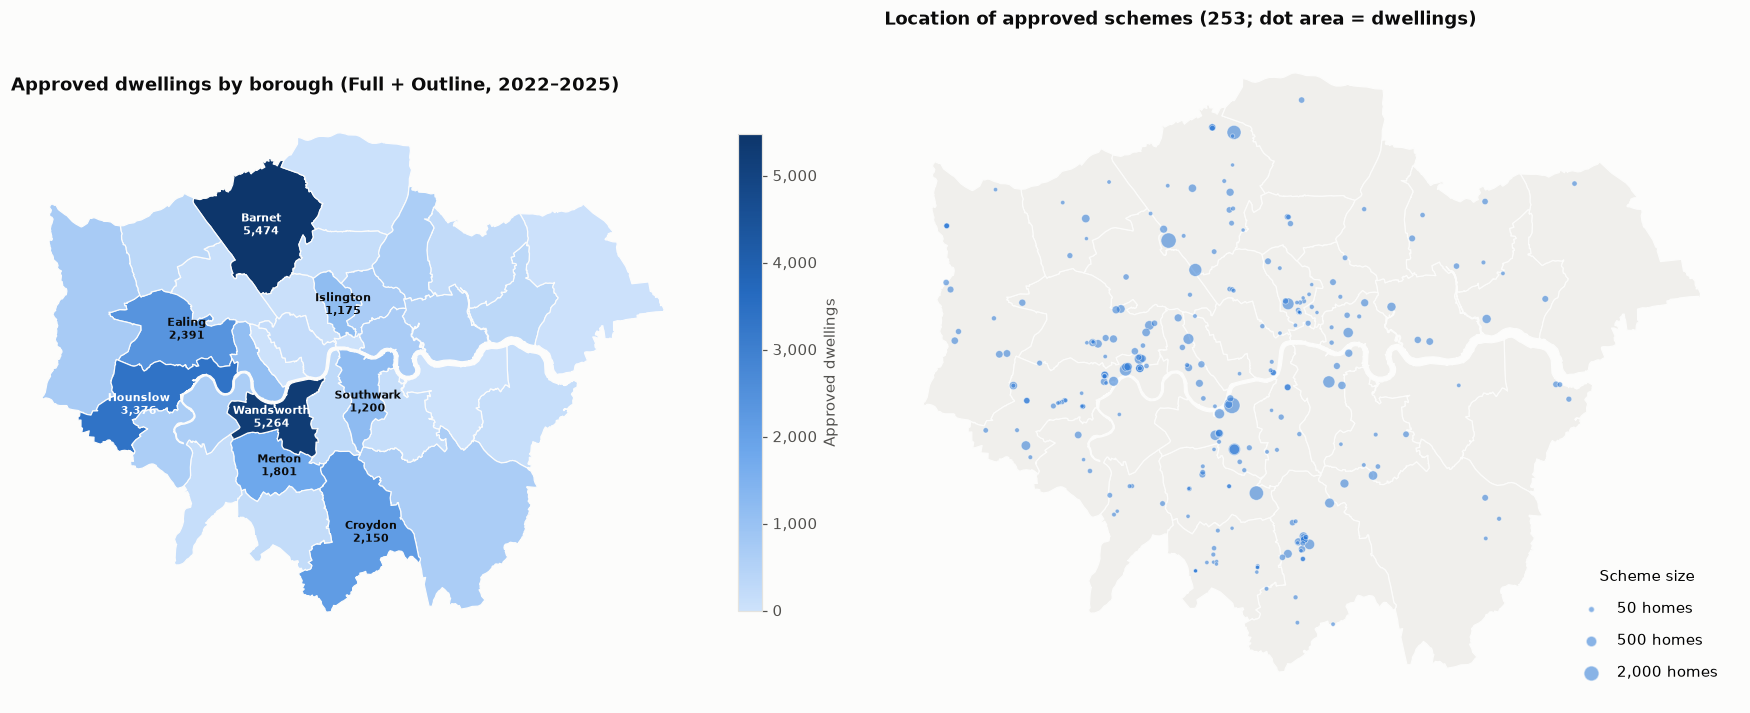

In [32]:
# Static maps (geopandas): borough totals, and where the individual schemes are
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))

ax = axes[0]
bmap.plot(column="approved_dwellings", cmap=SEQUENTIAL, linewidth=0.8, edgecolor="#fcfcfb", ax=ax,
          legend=True, legend_kwds={"shrink": 0.6, "label": "Approved dwellings", "format": "{x:,.0f}"})
top8 = bmap.nlargest(8, "approved_dwellings")
for _, r in top8.iterrows():
    pt = r.geometry.representative_point()
    ax.annotate(f"{r['borough']}\n{r['approved_dwellings']:,.0f}", (pt.x, pt.y), ha="center", va="center",
                fontsize=7, fontweight="bold",
                color="white" if r["approved_dwellings"] > 0.5 * bmap["approved_dwellings"].max() else INK)
ax.set_title("Approved dwellings by borough (Full + Outline, 2022–2025)", y=1.0, pad=12)
ax.set_axis_off()

ax = axes[1]
bmap.plot(color="#f0efec", edgecolor="#fcfcfb", linewidth=0.8, ax=ax)
pts = homes[homes["approved"] & homes["lat"].notna()].sort_values("n_dwellings", ascending=False)
ax.scatter(pts.geometry.x, pts.geometry.y, s=np.sqrt(pts["n_dwellings"]) * 2.2, color=APPROVED_C,
           alpha=0.55, edgecolor="#fcfcfb", linewidth=0.5)
for n in [50, 500, 2000]:
    ax.scatter([], [], s=np.sqrt(n) * 2.2, color=APPROVED_C, alpha=0.55, edgecolor="#fcfcfb", label=f"{n:,} homes")
ax.legend(title="Scheme size", loc="lower right", labelspacing=1.2, borderpad=1)
ax.set_title(f"Location of approved schemes ({len(pts):,}; dot area = dwellings)", y=1.0, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

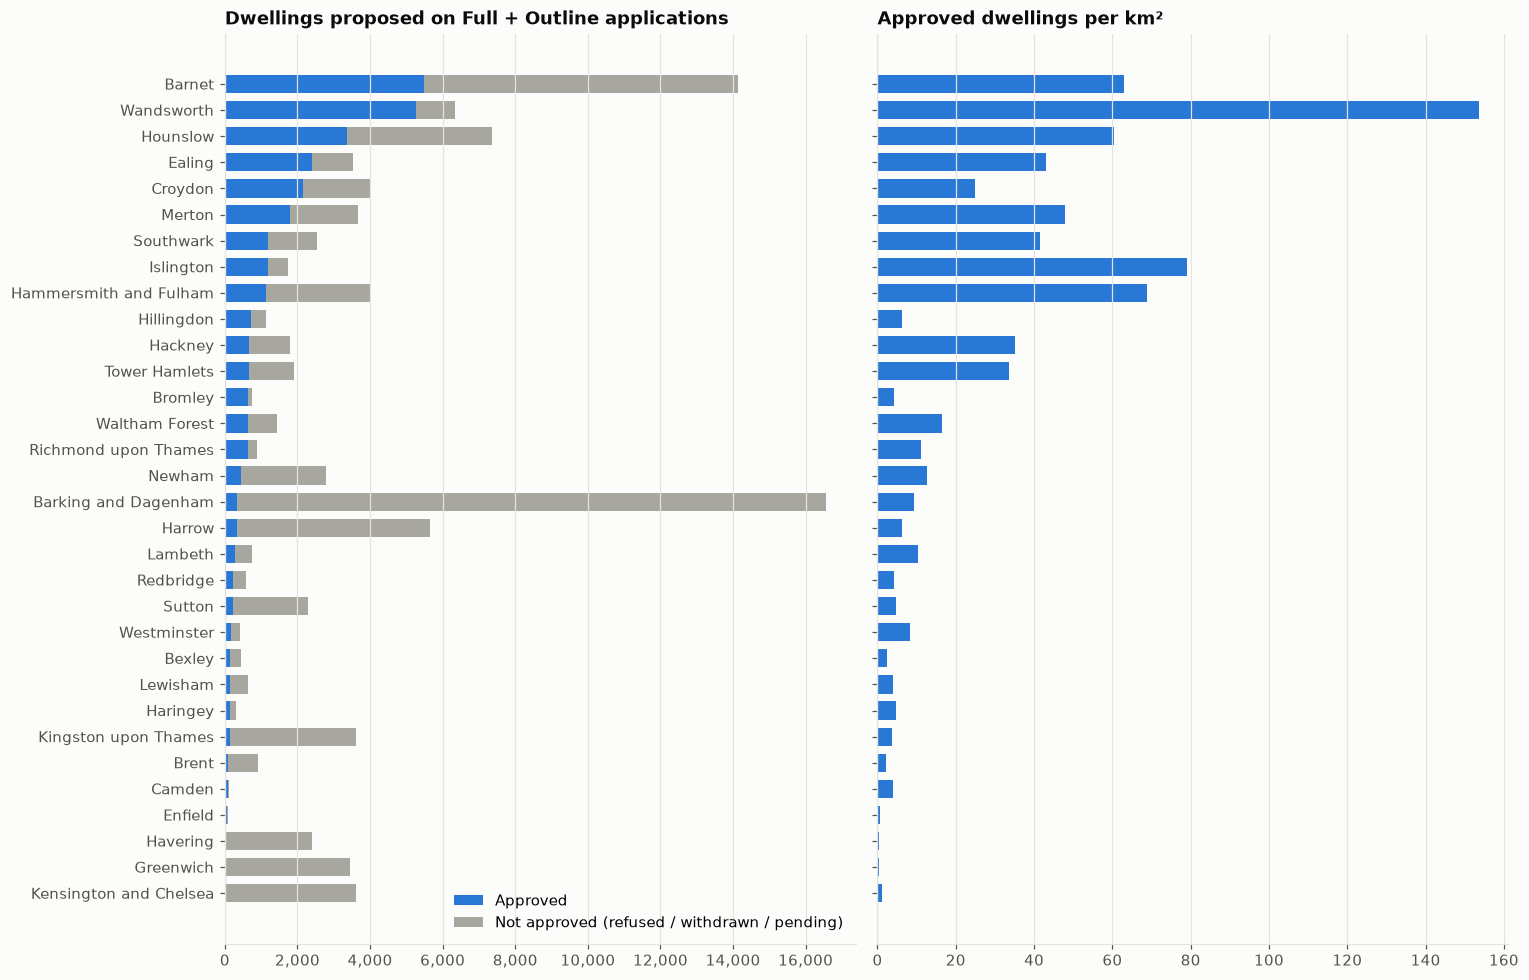

In [33]:
# Ranked view: map colour hides small differences, and big outer boroughs dominate visually
d = dwell.sort_values("approved_dwellings")
fig, axes = plt.subplots(1, 2, figsize=(14, 9), sharey=True)
axes[0].barh(d.index, d["approved_dwellings"], color=APPROVED_C, height=0.7, label="Approved")
axes[0].barh(d.index, d["proposed_dwellings"] - d["approved_dwellings"], left=d["approved_dwellings"],
             color=NEUTRAL_C, height=0.7, label="Not approved (refused / withdrawn / pending)")
axes[0].xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
axes[0].set_title("Dwellings proposed on Full + Outline applications")
axes[0].legend(loc="lower right")
axes[0].grid(axis="y", visible=False)

dens = bmap.set_index("borough").loc[d.index, "approved_per_km2"]
axes[1].barh(d.index, dens, color=APPROVED_C, height=0.7)
axes[1].set_title("Approved dwellings per km²")
axes[1].grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

In [34]:
# Interactive map (plotly): hover a borough for its figures, or a dot for the scheme.
# Uses geo traces drawn from the ONS polygons: no tile basemap, so no API key or tile server needed.
import json
import textwrap
import plotly.graph_objects as go

geojson = json.loads(bmap[["borough", "geometry"]].to_json())
fig = go.Figure()
fig.add_trace(go.Choropleth(
    geojson=geojson, featureidkey="properties.borough", locations=bmap["borough"],
    z=bmap["approved_dwellings"], name="Approved dwellings by borough",
    colorscale=[[0, "#cde2fb"], [0.33, "#6da7ec"], [0.66, "#256abf"], [1, "#0d366b"]],
    marker_line_color="#fcfcfb", marker_line_width=1,
    colorbar=dict(title="Approved<br>dwellings", tickformat=",", len=0.6, thickness=14),
    customdata=bmap[["proposed_dwellings", "schemes", "approved_per_km2"]].to_numpy(),
    hovertemplate=("<b>%{location}</b><br>Approved dwellings: %{z:,.0f}<br>Proposed dwellings: %{customdata[0]:,.0f}"
                   "<br>Schemes: %{customdata[1]:,.0f}<br>Approved per km²: %{customdata[2]:.1f}<extra></extra>"),
))

big = pts[pts["n_dwellings"] >= 100]
hover = [f"<b>{int(r.n_dwellings):,} homes</b> · {r.borough}<br>{r.start_date[:10]} · {r.app_type}<br>"
         + "<br>".join(textwrap.wrap(str(r.description)[:240], 60)) for r in big.itertuples()]
fig.add_trace(go.Scattergeo(
    lon=big.geometry.x, lat=big.geometry.y, mode="markers", name="Approved schemes (≥100 homes; area = homes)",
    marker=dict(size=big["n_dwellings"], sizemode="area", sizeref=2 * big["n_dwellings"].max() / 40 ** 2,
                sizemin=4, color="#eb6834", opacity=0.8, line=dict(color="#fcfcfb", width=1)),
    hovertext=hover, hoverinfo="text",
))

fig.update_geos(fitbounds="locations", visible=False, projection_type="mercator", bgcolor="#fcfcfb")
fig.update_layout(
    title=dict(text="Approved dwellings in London, Full + Outline applications 2022–2025", x=0.01),
    height=720, margin=dict(l=0, r=0, t=50, b=0), paper_bgcolor="#fcfcfb",
    legend=dict(orientation="h", yanchor="bottom", y=0.0, x=0.01, bgcolor="rgba(252,252,251,0.8)"),
    font=dict(family="Arial", size=12, color=INK_2),
)
fig.write_html("london_dwellings_map.html", include_plotlyjs=True)  # self-contained, works offline
fig

### What the dwelling maps show

The summary cell below prints the headline figures. Keep in mind that these totals come from the **larger schemes each borough reports with a dwelling count**, so boroughs whose portals rarely publish `n_dwellings` (such as Redbridge, Barking & Dagenham, Richmond and Waltham Forest) will look under-supplied even if they aren't. Some double counting can remain where an outline permission and its later reserved-matters application both appear with slightly different coordinates or dwelling numbers.

In [35]:
t = dwell.sort_values("approved_dwellings", ascending=False)
top5_share = t["approved_dwellings"].head(5).sum() / t["approved_dwellings"].sum()
print(f"Approved dwellings, London: {t['approved_dwellings'].sum():,.0f} "
      f"(of {t['proposed_dwellings'].sum():,.0f} proposed; {t['approved_dwellings'].sum() / t['proposed_dwellings'].sum():.0%})")
print("Top 5 boroughs:", ", ".join(f"{b} {v:,.0f}" for b, v in t["approved_dwellings"].head(5).items()),
      f"→ {top5_share:.0%} of the London total")
print("Bottom 5:      ", ", ".join(f"{b} {v:,.0f}" for b, v in t["approved_dwellings"].tail(5).items()))
print("Densest (approved per km²):", ", ".join(
    f"{b} {v:,.0f}" for b, v in bmap.set_index("borough")["approved_per_km2"].nlargest(5).items()))
print("\nInteractive map saved to london_dwellings_map.html")

Approved dwellings, London: 30,789 (of 99,810 proposed; 31%)
Top 5 boroughs: Barnet 5,474, Wandsworth 5,264, Hounslow 3,376, Ealing 2,391, Croydon 2,150 → 61% of the London total
Bottom 5:       Camden 85, Enfield 58, Havering 30, Greenwich 14, Kensington and Chelsea 13
Densest (approved per km²): Wandsworth 154, Islington 79, Hammersmith and Fulham 69, Barnet 63, Hounslow 60

Interactive map saved to london_dwellings_map.html


## 10. Available land, planning outcomes and population

**Questions**
1. How much *available* land (brownfield, industrial and undeveloped "virgin" land) does each borough have?
2. Are applications on these land types more or less likely to be approved?
3. Does population size or density constrain planning (application volume, approval, speed)?

The planning dataset has no land-use or population fields, so this section brings in external data (downloaded once into `data/`):

| Land type | Source | Notes |
|---|---|---|
| **Brownfield** | DLUHC *Brownfield Land Register* ([planning.data.gov.uk](https://www.planning.data.gov.uk/dataset/brownfield-land)) | Official. Each site has a location point, hectares and planning-permission status. Sites are assigned to boroughs by location. |
| **Industrial** | OpenStreetMap `landuse=industrial` (via `osmnx`) | Crowd-sourced. Covers ~4,900 ha, versus ~6,900 ha in the GLA's Industrial Land Supply study, so it undercounts. |
| **Virgin / greenfield** | OpenStreetMap `landuse=farmland / meadow / greenfield` | Undeveloped, non-park land. Most of it is also **Green Belt**, so it is protected rather than available. |
| **Green Belt** | DLUHC Green Belt ([planning.data.gov.uk](https://www.planning.data.gov.uk/dataset/green-belt)) | Official designation; used as a planning *constraint*. |
| **Population** | ONS mid-year estimates, 2025 (via Nomis) | |

**Register vintage matters.** Each borough maintains its own brownfield register, and some haven't updated theirs since 2017 (Bromley, Enfield, Harrow, Kingston, Sutton, Tower Hamlets, the City). Kingston lists only 2 sites. Low brownfield figures for those boroughs reflect an out-of-date register, not a lack of brownfield land.

Brownfield register sites are published as points, so each is drawn as a circle with the site's registered area when tagging applications. That approximation is only used for the application-level analysis.

In [36]:
from shapely import wkt

BNG = 27700  # British National Grid (metres), for areas and distances
b_bng = boroughs[["code", "borough", "geometry"]].to_crs(BNG)
b_bng["area_ha"] = b_bng.area / 1e4

# --- Brownfield Land Register: current London entries ---
blr = pd.read_csv("data/brownfield_land_register.csv", low_memory=False)
blr = blr[blr["end-date"].isna() & blr["point"].notna() & blr["hectares"].notna()].copy()
blr = gpd.GeoDataFrame(blr, geometry=blr["point"].map(wkt.loads), crs="EPSG:4326").to_crs(BNG)
blr = gpd.sjoin(blr, b_bng[["borough", "geometry"]], how="inner", predicate="within").drop(columns="index_right")
STATUS = {"permissioned": "Permissioned", "Planning Permission": "Permissioned", "completed": "Permissioned",
          "not-permissioned": "Not permissioned", "non-permissioned": "Not permissioned",
          "pending-decision": "Pending decision"}
blr["status"] = blr["planning-permission-status"].map(STATUS).fillna("Other / unknown")
print(f"London brownfield register sites: {len(blr):,}, {blr['hectares'].sum():,.0f} ha")
print(blr["status"].value_counts())

# --- OpenStreetMap land use (fetched once; cached in data/) ---
OSM_FILE = "data/osm_landuse_london.gpkg"
try:
    osm = gpd.read_file(OSM_FILE)
except Exception:
    import osmnx as ox  # needs internet; see note in section header
    tags = {"landuse": ["industrial", "brownfield", "greenfield", "farmland", "meadow", "construction"]}
    osm = ox.features_from_polygon(boroughs.union_all(), tags)
    osm = osm[osm.geometry.geom_type.isin(["Polygon", "MultiPolygon"])][["landuse", "name", "geometry"]].reset_index()
    osm.to_file(OSM_FILE, driver="GPKG")
osm = osm.to_crs(BNG)
osm["land_type"] = osm["landuse"].map({"industrial": "Industrial", "farmland": "Virgin / greenfield",
                                       "meadow": "Virgin / greenfield", "greenfield": "Virgin / greenfield"})
osm = osm[osm["land_type"].notna()]

# --- Green Belt (national file, clipped to London) ---
gb = gpd.read_file("data/green_belt_england.geojson", bbox=tuple(boroughs.total_bounds)).to_crs(BNG)
gb = gpd.GeoDataFrame(geometry=[gb.union_all()], crs=BNG)

# --- Population ---
pop = (pd.read_csv("data/population_boroughs.csv")
       .rename(columns={"GEOGRAPHY_CODE": "code", "OBS_VALUE": "population", "DATE_NAME": "pop_year"}))
print(f"\nPopulation year: {pop['pop_year'].iloc[0]}, London total {pop['population'].sum():,}")

London brownfield register sites: 4,918, 4,358 ha
status
Permissioned        3039
Not permissioned    1191
Other / unknown      579
Pending decision     109
Name: count, dtype: int64



Population year: 2025, London total 9,122,909


In [37]:
def area_by_borough(layer, label):
    """Hectares of a (dissolved) polygon layer inside each borough; overlapping polygons aren't double counted."""
    dissolved = gpd.GeoDataFrame(geometry=[layer.union_all()], crs=BNG)
    inter = gpd.overlay(b_bng[["borough", "geometry"]], dissolved, how="intersection")
    return (inter.area / 1e4).groupby(inter["borough"]).sum().rename(label)


land = b_bng.set_index("borough")[["code", "area_ha"]].join([
    blr.groupby("borough")["hectares"].sum().rename("brownfield_ha"),
    area_by_borough(osm[osm["land_type"] == "Industrial"], "industrial_ha"),
    area_by_borough(osm[osm["land_type"] == "Virgin / greenfield"], "greenfield_ha"),
    area_by_borough(gb, "green_belt_ha"),
]).fillna(0)
land = land.reset_index().merge(pop[["code", "population"]], on="code").set_index("borough")

land["available_ha"] = land[["brownfield_ha", "industrial_ha", "greenfield_ha"]].sum(axis=1)
for c in ["brownfield_ha", "industrial_ha", "greenfield_ha", "green_belt_ha", "available_ha"]:
    land[c.replace("_ha", "_pct")] = land[c] / land["area_ha"]
land["density_per_km2"] = land["population"] / (land["area_ha"] / 100)

# Brownfield register: share of sites (and hectares) that already have planning permission
blr_perm = blr.assign(perm=blr["status"] == "Permissioned").groupby("borough").agg(
    brownfield_sites=("perm", "size"), brownfield_permissioned_share=("perm", "mean"),
    brownfield_max_dwellings=("maximum-net-dwellings", "sum"),
    register_updated=("entry-date", "max"))
land = land.join(blr_perm)

print(f"London: brownfield {land['brownfield_ha'].sum():,.0f} ha · industrial (OSM) {land['industrial_ha'].sum():,.0f} ha · "
      f"virgin/greenfield (OSM) {land['greenfield_ha'].sum():,.0f} ha · Green Belt {land['green_belt_ha'].sum():,.0f} ha")
(land.sort_values("available_ha", ascending=False)
 [["population", "density_per_km2", "area_ha", "brownfield_ha", "industrial_ha", "greenfield_ha", "available_ha",
   "available_pct", "green_belt_pct", "brownfield_sites", "brownfield_permissioned_share", "register_updated"]]
 .style.format({"population": "{:,.0f}", "density_per_km2": "{:,.0f}", "area_ha": "{:,.0f}", "brownfield_ha": "{:,.0f}",
                "industrial_ha": "{:,.0f}", "greenfield_ha": "{:,.0f}", "available_ha": "{:,.0f}",
                "available_pct": "{:.1%}", "green_belt_pct": "{:.1%}", "brownfield_sites": "{:,.0f}",
                "brownfield_permissioned_share": "{:.0%}"}, na_rep="–")
 .background_gradient(subset=["available_ha"], cmap=SEQUENTIAL))

London: brownfield 4,358 ha · industrial (OSM) 4,720 ha · virgin/greenfield (OSM) 12,367 ha · Green Belt 34,789 ha


,population,density_per_km2,area_ha,brownfield_ha,industrial_ha,greenfield_ha,available_ha,available_pct,green_belt_pct,brownfield_sites,brownfield_permissioned_share,register_updated
borough,,,,,,,,,,,,
Bromley,"336,048","2,238","15,012",52,95,"3,644","3,792",25.3%,51.0%,89,87%,2017-12-31
Havering,"280,787","2,500","11,233",104,331,"2,518","2,953",26.3%,54.0%,106,67%,2021-02-19
Hillingdon,"326,671","2,823","11,572",180,387,"1,346","1,913",16.5%,42.1%,202,25%,2020-05-31
Enfield,"329,400","4,010","8,215",50,395,"1,196","1,641",20.0%,37.4%,27,100%,2017-12-31
Barnet,"408,087","4,701","8,681",556,77,969,"1,601",18.4%,27.5%,239,94%,2024-12-31
Barking and Dagenham,"238,295","6,601","3,610",615,455,81,"1,151",31.9%,14.6%,86,41%,2024-12-31
Redbridge,"321,829","5,708","5,638",128,61,539,728,12.9%,34.1%,188,37%,2025-11-24
Bexley,"257,103","4,244","6,059",82,391,175,648,10.7%,18.5%,101,63%,2024-12-19
Croydon,"410,085","4,740","8,651",173,150,319,642,7.4%,25.3%,490,69%,2020-12-22


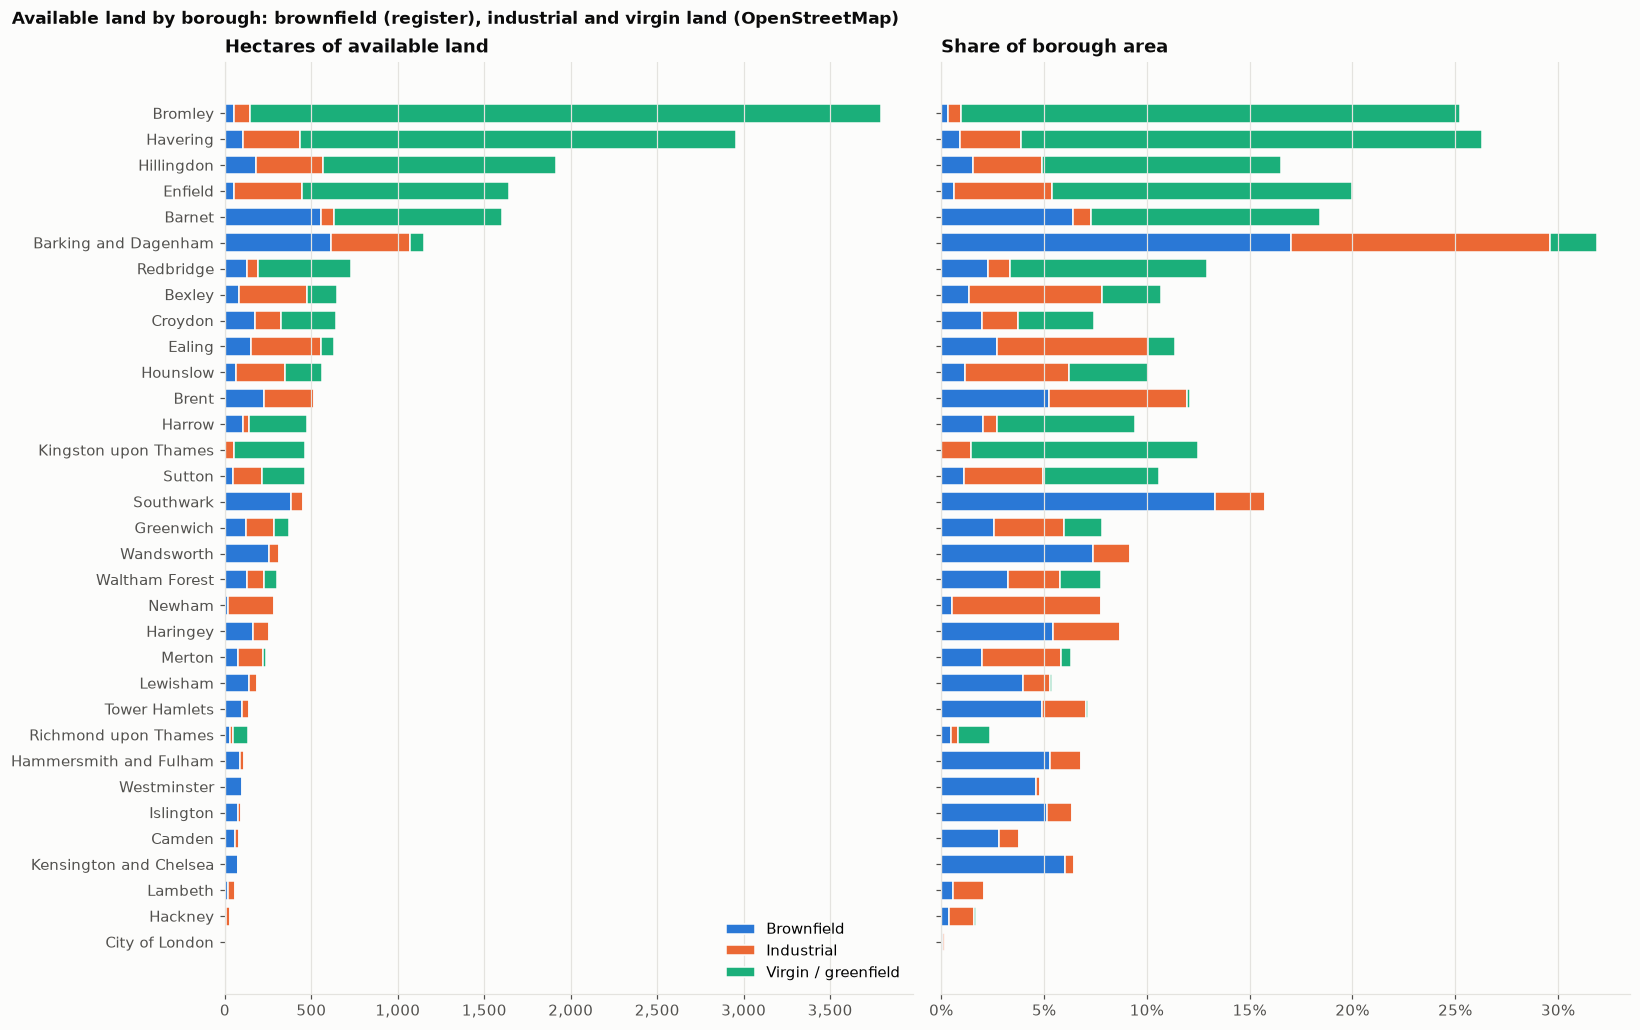

In [38]:
LAND_COLORS = {"Brownfield": "#2a78d6", "Industrial": "#eb6834", "Virgin / greenfield": "#1baf7a"}
d = land.sort_values("available_ha")
fig, axes = plt.subplots(1, 2, figsize=(15, 9.5), sharey=True)
for ax, suffix, title, fmt in [(axes[0], "_ha", "Hectares of available land", mtick.StrMethodFormatter("{x:,.0f}")),
                               (axes[1], "_pct", "Share of borough area", pct)]:
    left = np.zeros(len(d))
    for key, col in [("Brownfield", "brownfield"), ("Industrial", "industrial"), ("Virgin / greenfield", "greenfield")]:
        vals = d[col + suffix].values
        ax.barh(d.index, vals, left=left, color=LAND_COLORS[key], height=0.72, label=key,
                edgecolor="#fcfcfb", linewidth=1)
        left += vals
    ax.xaxis.set_major_formatter(fmt)
    ax.set_title(title)
    ax.grid(axis="y", visible=False)
axes[0].legend(loc="lower right")
fig.suptitle("Available land by borough: brownfield (register), industrial and virgin land (OpenStreetMap)",
             x=0.01, ha="left", fontweight="bold", color=INK)
plt.tight_layout()
plt.show()

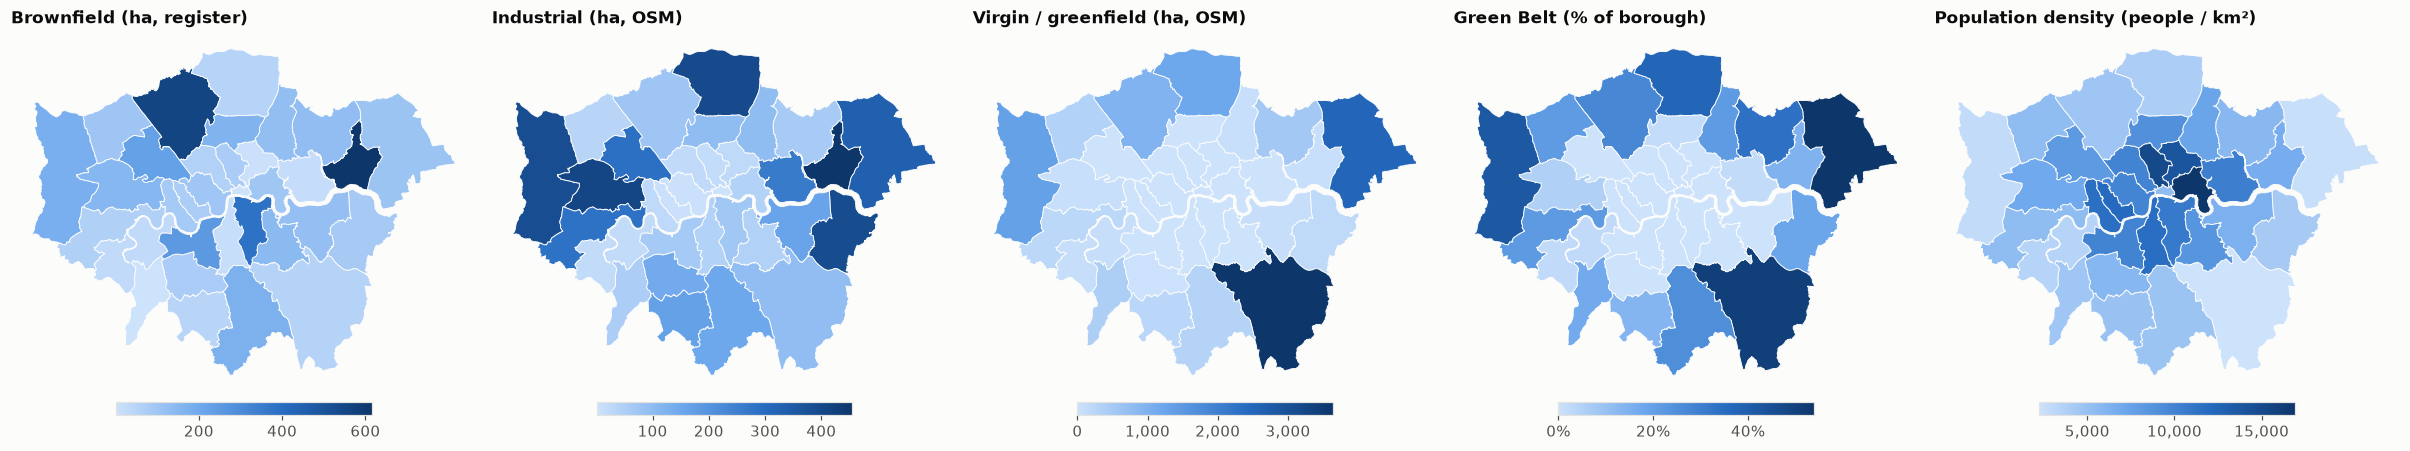

In [39]:
# Small-multiple maps: where each land type is, plus the Green Belt constraint
lmap = b_bng.merge(land.reset_index()[["borough", "brownfield_ha", "industrial_ha", "greenfield_ha", "green_belt_pct",
                                       "density_per_km2"]], on="borough")
panels = [("brownfield_ha", "Brownfield (ha, register)", "{x:,.0f}"),
          ("industrial_ha", "Industrial (ha, OSM)", "{x:,.0f}"),
          ("greenfield_ha", "Virgin / greenfield (ha, OSM)", "{x:,.0f}"),
          ("green_belt_pct", "Green Belt (% of borough)", None),
          ("density_per_km2", "Population density (people / km²)", "{x:,.0f}")]
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, (col_, title, fmt) in zip(axes, panels):
    lmap.plot(column=col_, cmap=SEQUENTIAL, edgecolor="#fcfcfb", linewidth=0.6, ax=ax, legend=True,
              legend_kwds={"shrink": 0.55, "orientation": "horizontal", "pad": 0.02,
                           "format": fmt if fmt else mtick.PercentFormatter(1.0, decimals=0)})
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

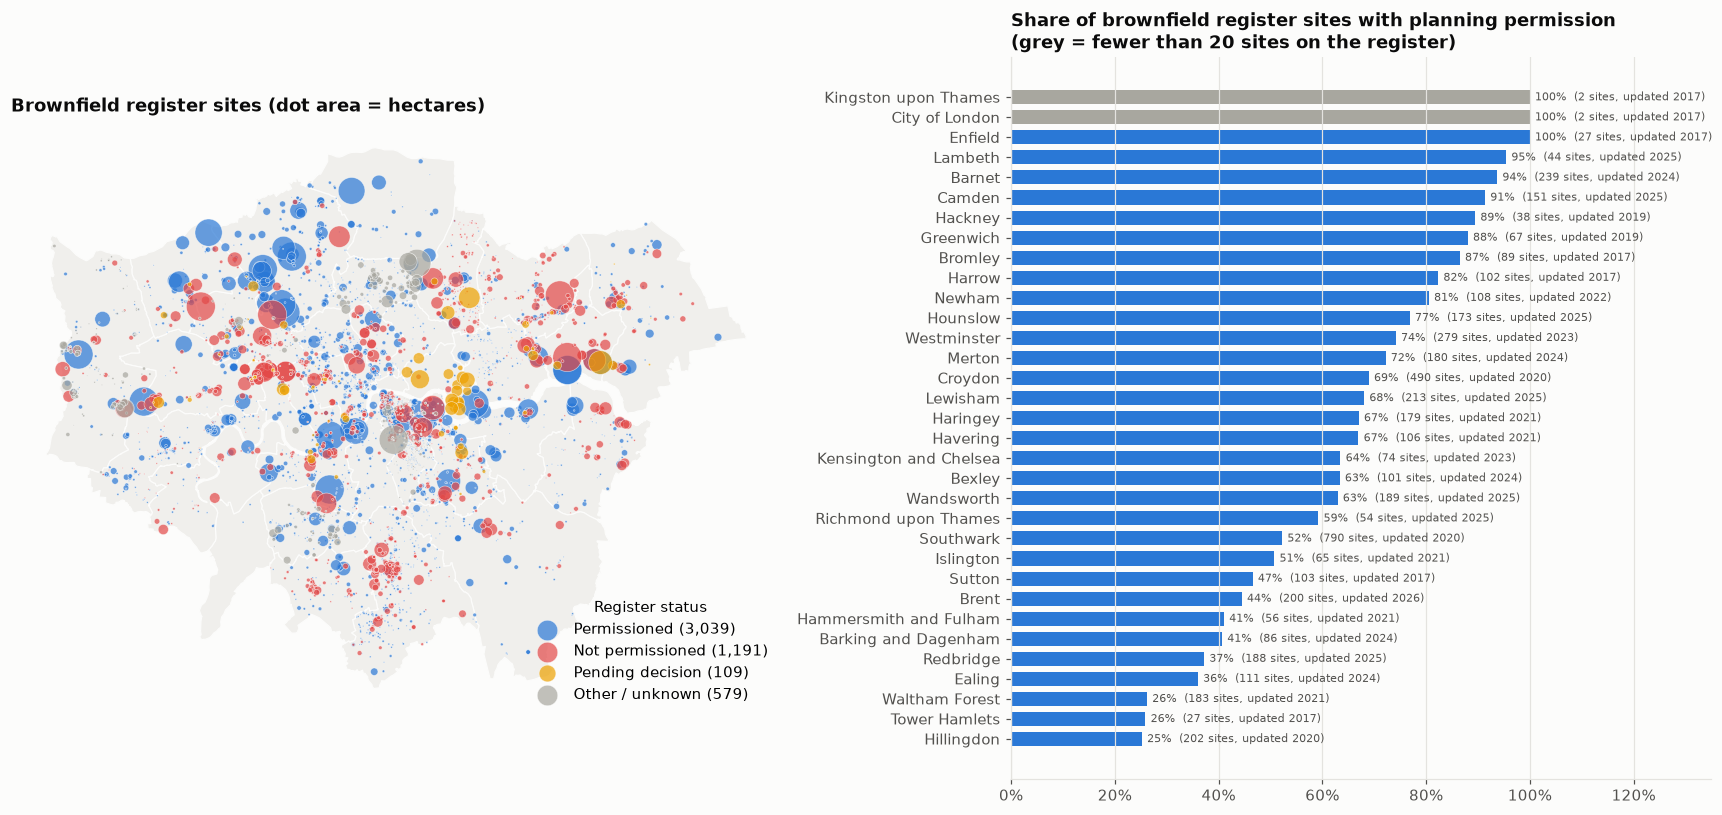

In [40]:
# Official brownfield sites and their permission status
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), gridspec_kw={"width_ratios": [1.1, 1]})
ax = axes[0]
b_bng.plot(color="#f0efec", edgecolor="#fcfcfb", linewidth=0.8, ax=ax)
STATUS_COLORS = {"Permissioned": "#2a78d6", "Not permissioned": "#e34948", "Pending decision": "#eda100",
                 "Other / unknown": "#a8a79f"}
for s_, c_ in STATUS_COLORS.items():
    sub = blr[blr["status"] == s_]
    ax.scatter(sub.geometry.x, sub.geometry.y, s=np.clip(sub["hectares"], 0.05, 30) * 12, color=c_, alpha=0.7,
               edgecolor="#fcfcfb", linewidth=0.4, label=f"{s_} ({len(sub):,})")
ax.legend(loc="lower right", title="Register status")
ax.set_title("Brownfield register sites (dot area = hectares)")
ax.set_axis_off()

ax = axes[1]
bp_ = land["brownfield_permissioned_share"].dropna().sort_values()
few = land.loc[bp_.index, "brownfield_sites"] < 20
ax.barh(bp_.index, bp_.values, color=np.where(few, NEUTRAL_C, APPROVED_C), height=0.7)
for yi, (b_, v) in enumerate(bp_.items()):
    ax.text(v + 0.01, yi, f"{v:.0%}  ({int(land.loc[b_, 'brownfield_sites'])} sites, updated {land.loc[b_, 'register_updated'][:4]})",
            va="center", fontsize=7.5, color=INK_2)
ax.set_xlim(0, 1.35)
ax.xaxis.set_major_formatter(pct)
ax.grid(axis="y", visible=False)
ax.set_title("Share of brownfield register sites with planning permission\n(grey = fewer than 20 sites on the register)")
plt.tight_layout()
plt.show()

### 10b. Is an application more likely to be approved on brownfield, industrial or virgin land?

Each decided full application with coordinates is tagged by the land it sits on, in this order of priority: brownfield register site → industrial → virgin/greenfield → **existing urban land** (everything else, mostly homes and high streets). Green Belt is tagged separately, because it overlaps the other categories.

Most full applications are householder extensions on existing urban land. To compare like with like, results are also shown for **Medium and Large** applications only.

In [41]:
apps = dec[dec["lat"].notna()].copy()
apps = gpd.GeoDataFrame(apps, geometry=gpd.points_from_xy(apps["lng"], apps["lat"]), crs="EPSG:4326").to_crs(BNG)

# Brownfield sites as circles with the registered area (min radius 20 m to allow for geocoding offsets)
blr_poly = blr[["hectares", "geometry"]].copy()
blr_poly["geometry"] = blr_poly.buffer(np.maximum(np.sqrt(blr_poly["hectares"] * 1e4 / np.pi), 20))


def within(points, polys):
    hit = gpd.sjoin(points[["geometry"]], polys[["geometry"]], how="inner", predicate="within")
    return points.index.isin(hit.index)


apps["on_brownfield"] = within(apps, blr_poly)
apps["on_industrial"] = within(apps, osm[osm["land_type"] == "Industrial"])
apps["on_greenfield"] = within(apps, osm[osm["land_type"] == "Virgin / greenfield"])
apps["in_green_belt"] = within(apps, gb)
apps["land_type"] = np.select([apps["on_brownfield"], apps["on_industrial"], apps["on_greenfield"]],
                              ["Brownfield", "Industrial", "Virgin / greenfield"], default="Existing urban")

# Borough by location (so development-corporation applications land in their host borough)
apps = gpd.sjoin(apps, b_bng[["borough", "geometry"]], how="left", predicate="within").drop(columns="index_right")
apps["borough"] = apps["borough"].fillna(apps["area_name"].replace(NAME_FIX))


def rate_table(df, by):
    t = df.groupby(by).agg(n=("approved", "size"), approved=("approved", "sum"), median_days=("valid_days", "median"))
    t["approval_rate"] = t["approved"] / t["n"]
    t["ci_low"], t["ci_high"] = wilson_ci(t["approved"], t["n"])
    return t


LAND_ORDER = ["Existing urban", "Brownfield", "Industrial", "Virgin / greenfield"]
big_apps = apps[apps["app_size"].isin(["Medium", "Large"])]
rt_all = rate_table(apps, "land_type").reindex(LAND_ORDER)
rt_big = rate_table(big_apps, "land_type").reindex(LAND_ORDER)
gbt = rate_table(apps.assign(gb=np.where(apps["in_green_belt"], "In Green Belt", "Outside Green Belt")), "gb")
print("All decided full applications\n", rt_all.round(3), "\n")
print("Medium + Large applications only\n", rt_big.round(3), "\n")
print("Green Belt\n", gbt.round(3))

All decided full applications
                          n  approved  median_days  approval_rate  ci_low  ci_high
land_type                                                                        
Existing urban       79712     62503         63.0          0.784   0.781    0.787
Brownfield            1595      1311         78.0          0.822   0.802    0.840
Industrial             393       301         93.0          0.766   0.722    0.805
Virgin / greenfield     42        22        107.0          0.524   0.377    0.666 

Medium + Large applications only
                         n  approved  median_days  approval_rate  ci_low  ci_high
land_type                                                                       
Existing urban       7750      6748         95.0          0.871   0.863    0.878
Brownfield            466       436        111.0          0.936   0.910    0.955
Industrial            137       121        164.0          0.883   0.819    0.927
Virgin / greenfield    17         7 

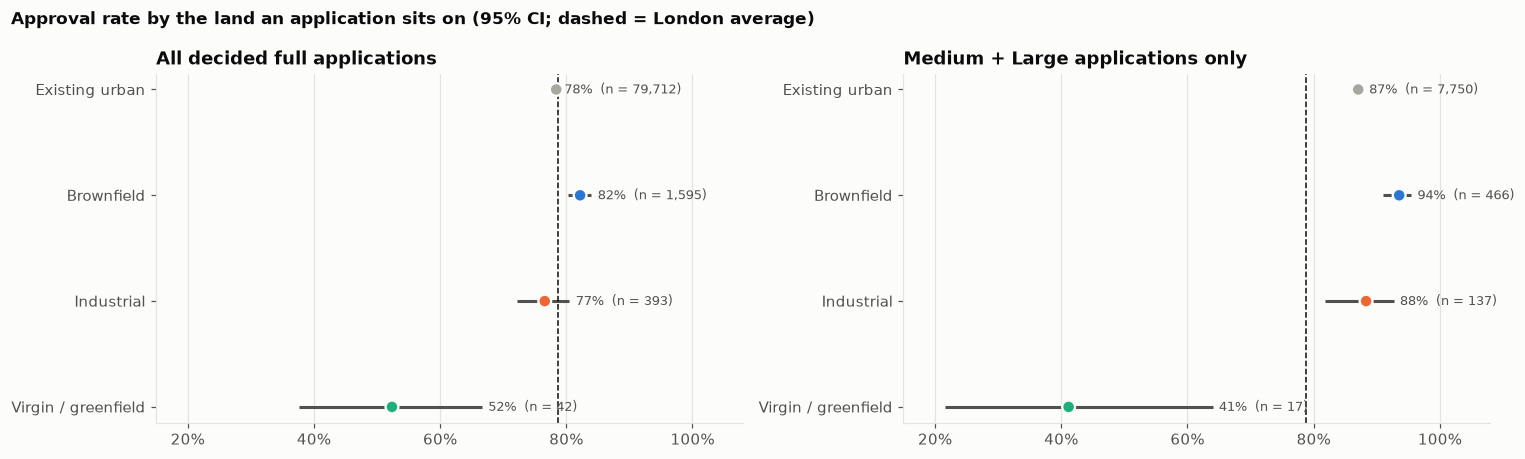

Land type vs outcome (all): χ² = 31.0, p = 8.53e-07, Cramér's V = 0.019
Land type vs outcome (Medium+Large): χ² = 49.8, p = 8.94e-11, Cramér's V = 0.075


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharex=True)
for ax, t, title in [(axes[0], rt_all, "All decided full applications"),
                     (axes[1], rt_big, "Medium + Large applications only")]:
    y = np.arange(len(t))[::-1]
    ax.hlines(y, t["ci_low"], t["ci_high"], color=INK_2, lw=2)
    ax.scatter(t["approval_rate"], y, s=70, zorder=3, edgecolor="#fcfcfb", linewidth=1.5,
               color=[LAND_COLORS.get(k, NEUTRAL_C) for k in t.index])
    for yi, (k, r) in zip(y, t.iterrows()):
        ax.text(r["ci_high"] + 0.01, yi, f"{r['approval_rate']:.0%}  (n = {int(r['n']):,})", va="center", fontsize=8.5, color=INK_2)
    ax.set_yticks(y, t.index)
    ax.axvline(LONDON_APPROVAL, color=INK, ls="--", lw=1)
    ax.xaxis.set_major_formatter(pct)
    ax.set_xlim(0.15, 1.08)
    ax.grid(axis="y", visible=False)
    ax.set_title(title)
fig.suptitle("Approval rate by the land an application sits on (95% CI; dashed = London average)",
             x=0.01, ha="left", fontweight="bold", color=INK)
plt.tight_layout()
plt.show()

v, chi2, p, dof = cramers_v(apps["land_type"], apps["approved"])
print(f"Land type vs outcome (all): χ² = {chi2:,.1f}, p = {p:.2e}, Cramér's V = {v:.3f}")
v, chi2, p, dof = cramers_v(big_apps["land_type"], big_apps["approved"])
print(f"Land type vs outcome (Medium+Large): χ² = {chi2:,.1f}, p = {p:.2e}, Cramér's V = {v:.3f}")

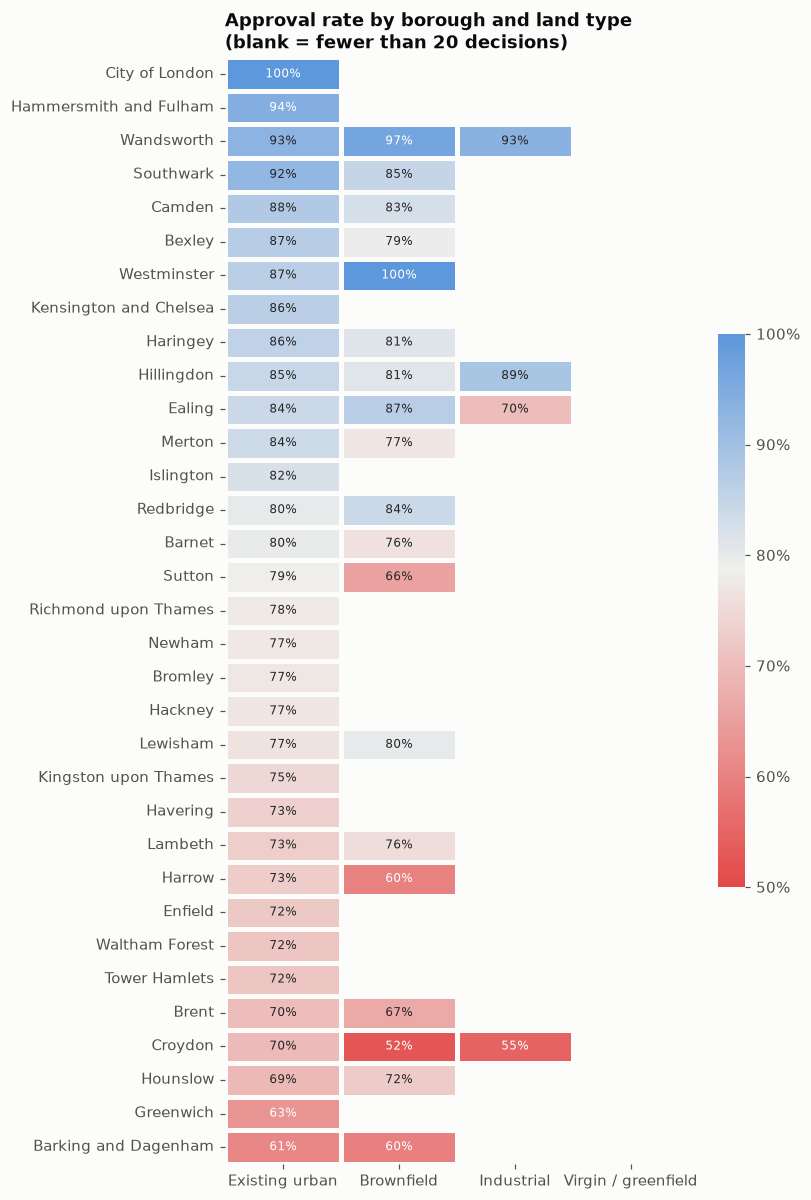

In [43]:
# Approval by land type within each borough (cells need ≥ 20 decisions)
bt = apps.groupby(["borough", "land_type"])["approved"].agg(["mean", "size"])
heat = bt["mean"].where(bt["size"] >= 20).unstack()[LAND_ORDER]
heat = heat.loc[heat["Existing urban"].sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(7.5, 11))
sns.heatmap(heat, cmap=DIVERGING, vmin=0.5, vmax=1.0, center=LONDON_APPROVAL, annot=True, fmt=".0%",
            annot_kws={"size": 8}, linewidths=2, linecolor="#fcfcfb", cbar_kws={"shrink": 0.5, "format": pct}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)
ax.set_title("Approval rate by borough and land type\n(blank = fewer than 20 decisions)")
plt.tight_layout()
plt.show()

### 10c. Does population size or density constrain planning?

A borough can't be "constrained" by population directly, so this looks at four things that would show a constraint:
- **Demand:** applications per 1,000 residents.
- **Selectivity:** the approval rate.
- **Capacity:** the median decision time and the share decided in time.
- **Output:** approved dwellings per 1,000 residents, from section 9.

The unit is the borough (n = 32, City of London excluded), so Spearman's ρ is used with its p-value.

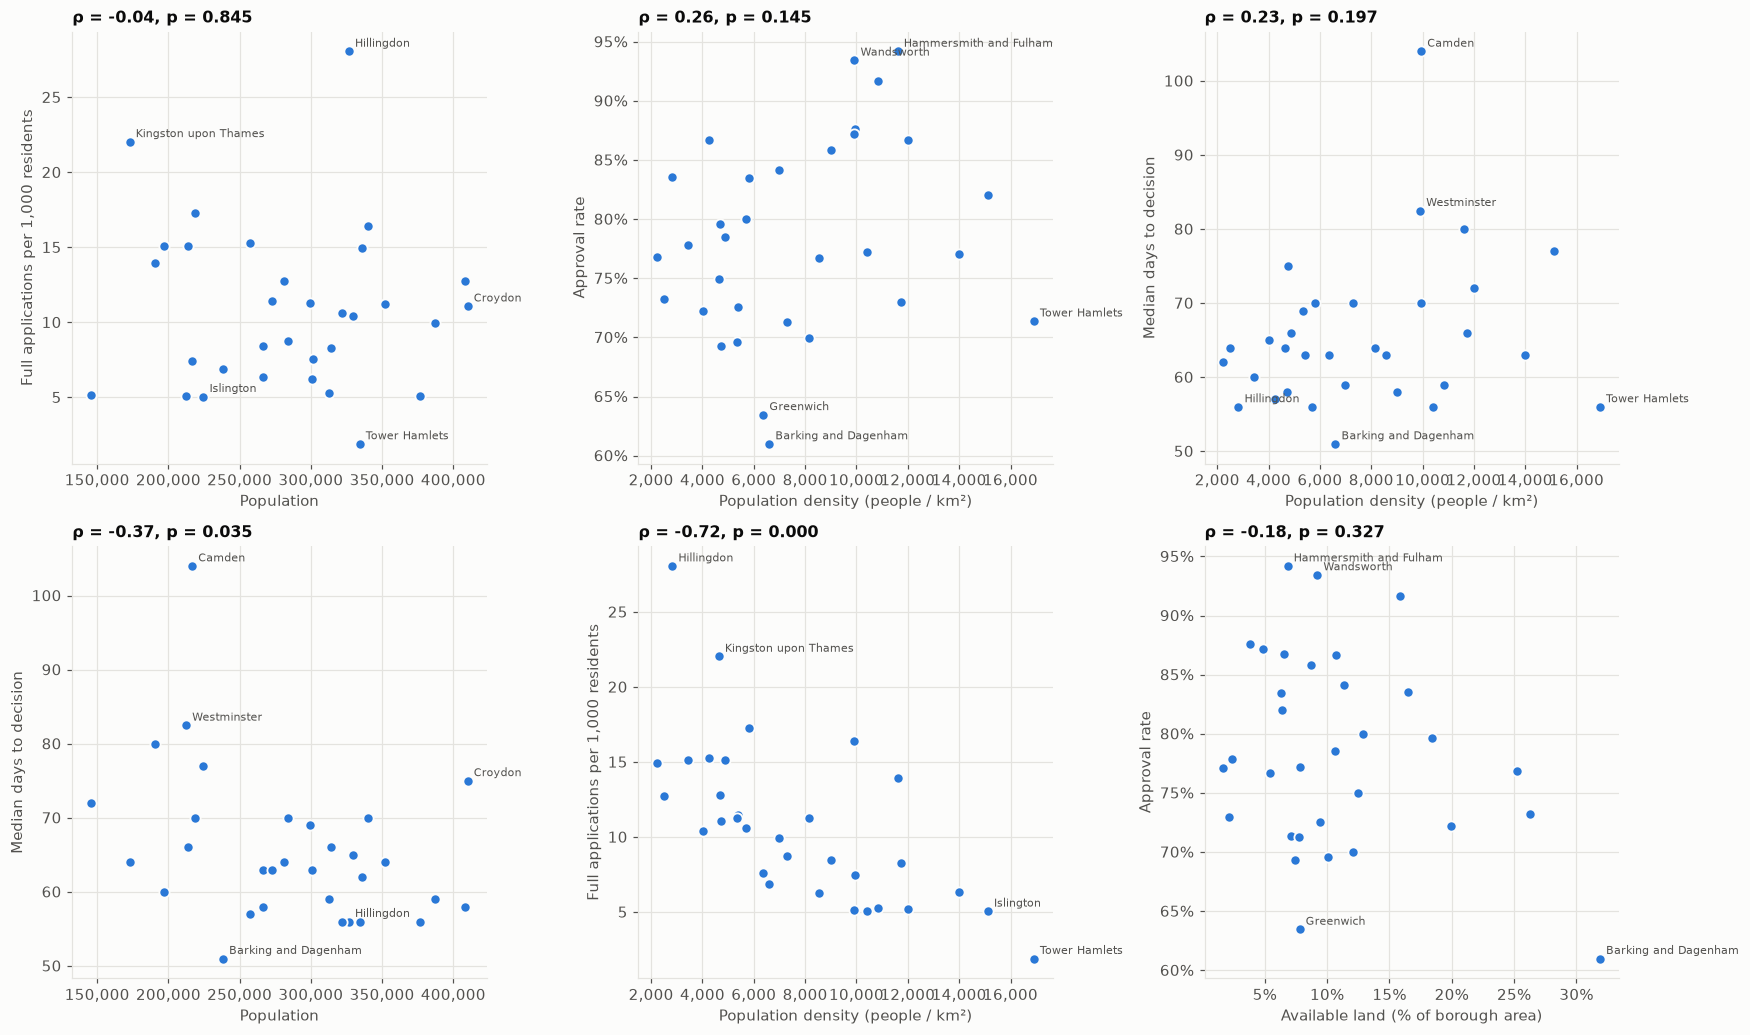

In [44]:
pb = land.join(borough.rename(index=NAME_FIX)[["total_full", "decided", "approval_rate", "median_days", "in_time", "reliable"]])
pb = pb.join(dwell["approved_dwellings"]).fillna({"approved_dwellings": 0})
pb = pb[pb["reliable"].fillna(False).astype(bool)]
pb["apps_per_1k"] = pb["total_full"] / pb["population"] * 1000
pb["dwellings_per_1k"] = pb["approved_dwellings"] / pb["population"] * 1000

pairs = [("population", "apps_per_1k", "Population", "Full applications per 1,000 residents"),
         ("density_per_km2", "approval_rate", "Population density (people / km²)", "Approval rate"),
         ("density_per_km2", "median_days", "Population density (people / km²)", "Median days to decision"),
         ("population", "median_days", "Population", "Median days to decision"),
         ("density_per_km2", "apps_per_1k", "Population density (people / km²)", "Full applications per 1,000 residents"),
         ("available_pct", "approval_rate", "Available land (% of borough area)", "Approval rate")]
fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))
for ax, (x_, y_, xl, yl) in zip(axes.flat, pairs):
    r_, p_ = stats.spearmanr(pb[x_], pb[y_])
    ax.scatter(pb[x_], pb[y_], s=45, color=APPROVED_C, edgecolor="#fcfcfb", linewidth=1.2, zorder=3)
    for name in pd.concat([pb[y_].nlargest(2), pb[y_].nsmallest(2), pb[x_].nlargest(1)]).index.unique():
        ax.annotate(name, (pb.loc[name, x_], pb.loc[name, y_]), xytext=(4, 3), textcoords="offset points",
                    fontsize=7.5, color=INK_2)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f"ρ = {r_:.2f}, p = {p_:.3f}", fontsize=10.5)
    if y_ == "approval_rate":
        ax.yaxis.set_major_formatter(pct)
    if x_ == "available_pct":
        ax.xaxis.set_major_formatter(pct)
    ax.xaxis.set_major_formatter(pct if x_ == "available_pct" else mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()

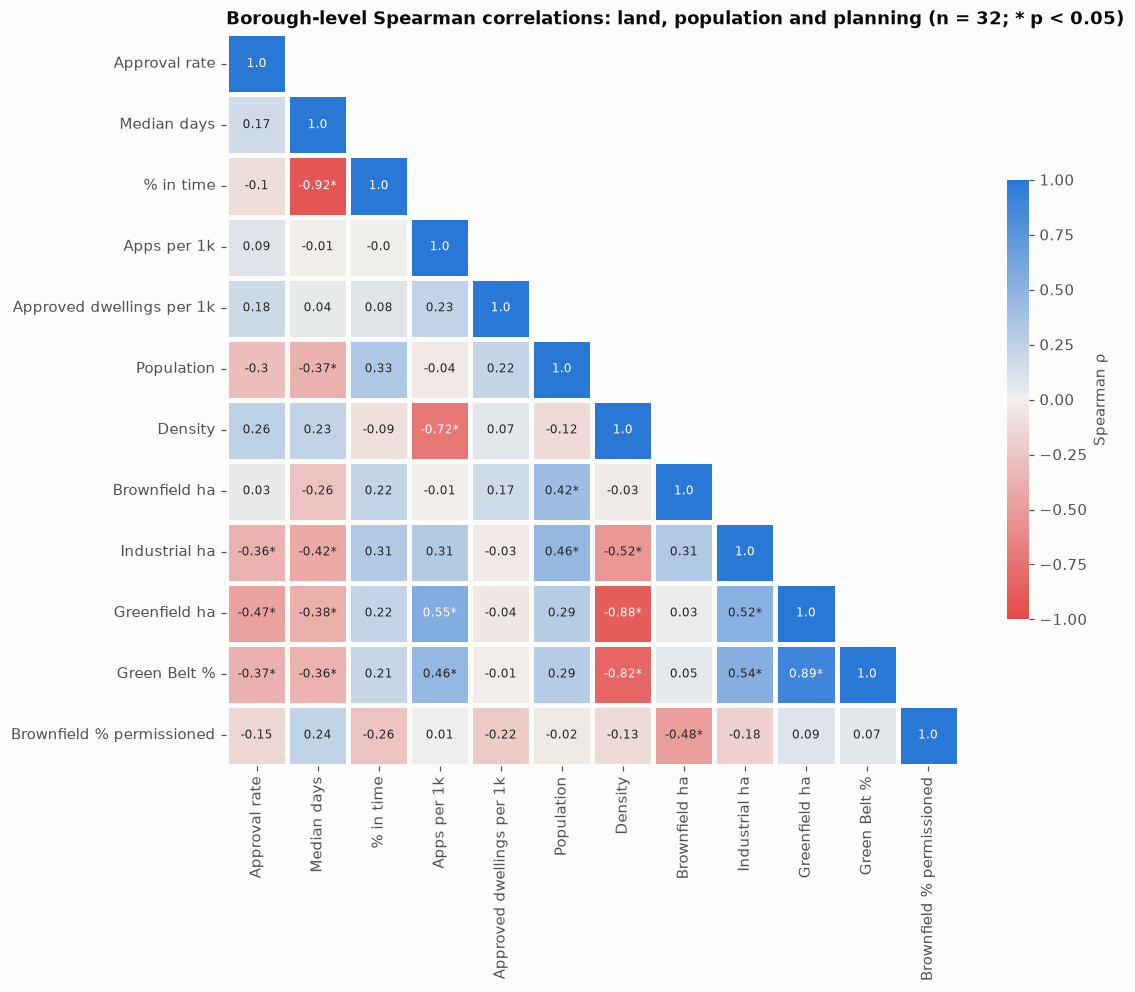

In [45]:
lvars = ["approval_rate", "median_days", "in_time", "apps_per_1k", "dwellings_per_1k", "population", "density_per_km2",
         "brownfield_ha", "industrial_ha", "greenfield_ha", "green_belt_pct", "brownfield_permissioned_share"]
llabels = ["Approval rate", "Median days", "% in time", "Apps per 1k", "Approved dwellings per 1k", "Population",
           "Density", "Brownfield ha", "Industrial ha", "Greenfield ha", "Green Belt %", "Brownfield % permissioned"]
lrho = pb[lvars].corr(method="spearman")
lp = pd.DataFrame(1.0, index=lvars, columns=lvars)
for i in lvars:
    for j in lvars:
        if i != j:
            pair = pb[[i, j]].dropna()
            lp.loc[i, j] = stats.spearmanr(pair[i], pair[j]).pvalue
annot = lrho.round(2).astype(str) + np.where(lp < 0.05, "*", "")
mask = np.triu(np.ones_like(lrho, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(lrho, mask=mask, cmap=DIVERGING, vmin=-1, vmax=1, center=0, annot=annot, fmt="", annot_kws={"size": 8},
            linewidths=2, linecolor="#fcfcfb", square=True, xticklabels=llabels, yticklabels=llabels,
            cbar_kws={"shrink": 0.6, "label": "Spearman ρ"}, ax=ax)
ax.grid(False)
ax.set_title(f"Borough-level Spearman correlations: land, population and planning (n = {len(pb)}; * p < 0.05)")
plt.tight_layout()
plt.show()

### 10d. Putting it together: a logistic regression of approval

The comparisons above look at one factor at a time. This model estimates each factor **holding the others constant**:

`approved ~ land type + in Green Belt + application size + log2(borough density) + start year`

It reports odds ratios, where values above 1 mean more likely to be approved. Density is a borough-level variable, so its confidence interval comes from a **cluster bootstrap by borough** (resampling whole boroughs, 200 repetitions). Ordinary standard errors would overstate the certainty with only 32 boroughs.

c:\Users\Student\Housing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


c:\Users\Student\Housing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


c:\Users\Student\Housing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Student\Housing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


c:\Users\Student\Housing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


c:\Users\Student\Housing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Student\Housing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


...

c:\Users\Student\Housing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Student\Housing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


c:\Users\Student\Housing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Student\Housing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


c:\Users\Student\Housing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Student\Housing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


c:\Users\Student\Housing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Student\Housing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Applications in model: 77,503
                                         odds_ratio  ci_low  ci_high
Brownfield (vs existing urban)                1.062   0.722    1.445
Industrial (vs existing urban)                0.822   0.558    1.169
Virgin / greenfield (vs existing urban)       0.823   0.240    1.002
Large (vs Small)                              2.082   1.110    3.061
Medium (vs Small)                             1.970   1.323    2.882
In Green Belt                                 0.441   0.308    0.760
Borough density doubled                       1.199   0.955    1.575
Each later start year                         1.075   1.020    1.125


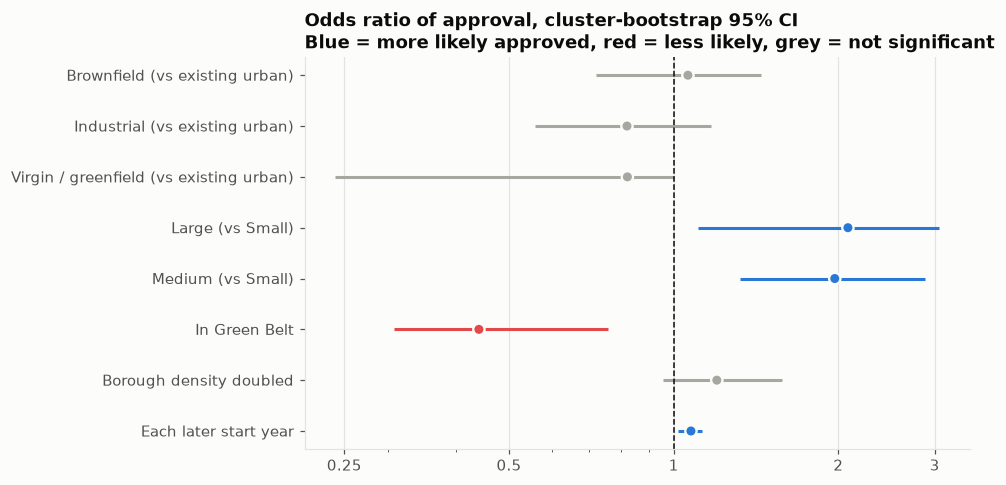

In [46]:
from sklearn.linear_model import LogisticRegression

model_df = apps.merge(land[["density_per_km2"]], left_on="borough", right_index=True, how="inner")
model_df = model_df[model_df["app_size"].notna() & model_df["borough"].isin(pb.index)].copy()
X = pd.get_dummies(model_df[["land_type", "app_size"]].astype("category"), drop_first=False)
X = X.drop(columns=["land_type_Existing urban", "app_size_Small"])  # reference levels
X["in_green_belt"] = model_df["in_green_belt"].astype(int)
X["log_density"] = np.log2(model_df["density_per_km2"])
X["log_density"] -= X["log_density"].mean()
X["start_year"] = model_df["start_year"] - 2022
X = X.astype(float)
y_ = model_df["approved"].values

logit = LogisticRegression(penalty=None, max_iter=2000).fit(X, y_)
coefs = pd.Series(logit.coef_[0], index=X.columns)

rng = np.random.default_rng(42)
groups = model_df["borough"].values
uniq = np.unique(groups)
idx_by_group = {g: np.flatnonzero(groups == g) for g in uniq}
boot = []
for _ in range(200):
    pick = rng.choice(uniq, size=len(uniq), replace=True)
    ix = np.concatenate([idx_by_group[g] for g in pick])
    boot.append(LogisticRegression(penalty=None, max_iter=2000).fit(X.iloc[ix], y_[ix]).coef_[0])
boot = pd.DataFrame(boot, columns=X.columns)

LABELS = {"land_type_Brownfield": "Brownfield (vs existing urban)", "land_type_Industrial": "Industrial (vs existing urban)",
          "land_type_Virgin / greenfield": "Virgin / greenfield (vs existing urban)", "in_green_belt": "In Green Belt",
          "app_size_Medium": "Medium (vs Small)", "app_size_Large": "Large (vs Small)",
          "log_density": "Borough density doubled", "start_year": "Each later start year"}
or_tbl = pd.DataFrame({"odds_ratio": np.exp(coefs), "ci_low": np.exp(boot.quantile(0.025)),
                       "ci_high": np.exp(boot.quantile(0.975))}).rename(index=LABELS)
print(f"Applications in model: {len(X):,}")
print(or_tbl.round(3))

fig, ax = plt.subplots(figsize=(9, 4.5))
t = or_tbl.iloc[::-1]
y = np.arange(len(t))
sig = (t["ci_low"] > 1) | (t["ci_high"] < 1)
col = np.where(~sig, NEUTRAL_C, np.where(t["odds_ratio"] > 1, APPROVED_C, REJECTED_C))
ax.hlines(y, t["ci_low"], t["ci_high"], color=col, lw=2)
ax.scatter(t["odds_ratio"], y, color=col, s=55, zorder=3, edgecolor="#fcfcfb", linewidth=1.5)
ax.axvline(1, color=INK, lw=1, ls="--")
ax.set_xscale("log")
ax.set_xticks([0.25, 0.5, 1, 2, 3])
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:g}"))
ax.xaxis.set_minor_formatter(mtick.NullFormatter())
ax.set_yticks(y, t.index)
ax.grid(axis="y", visible=False)
ax.set_title("Odds ratio of approval, cluster-bootstrap 95% CI\nBlue = more likely approved, red = less likely, grey = not significant")
plt.tight_layout()
plt.show()

In [47]:
lt = land.sort_values("available_ha", ascending=False)
print(f"""KEY NUMBERS: land, population and planning
- London: {land['brownfield_ha'].sum():,.0f} ha brownfield on the register ({len(blr):,} sites), {land['industrial_ha'].sum():,.0f} ha industrial (OSM),
  {land['greenfield_ha'].sum():,.0f} ha virgin/greenfield (OSM); Green Belt covers {land['green_belt_ha'].sum():,.0f} ha ({land['green_belt_ha'].sum() / land['area_ha'].sum():.0%} of London).
- Most available land: {', '.join(f"{b} {v:,.0f} ha" for b, v in lt['available_ha'].head(4).items())}
- Least available land: {', '.join(f"{b} {v:,.0f} ha" for b, v in lt['available_ha'].tail(4).items())}
- Most brownfield: {', '.join(f"{b} {v:,.0f} ha" for b, v in land['brownfield_ha'].nlargest(4).items())}
- Approval by land type (all / Medium+Large): """
      + "; ".join(f"{k} {rt_all.loc[k, 'approval_rate']:.0%} / {rt_big.loc[k, 'approval_rate']:.0%}" for k in LAND_ORDER)
      + f"""
- Green Belt: {gbt.loc['In Green Belt', 'approval_rate']:.0%} approved (n = {int(gbt.loc['In Green Belt', 'n']):,}) vs {gbt.loc['Outside Green Belt', 'approval_rate']:.0%} outside.
- Density vs approval rate: ρ = {stats.spearmanr(pb['density_per_km2'], pb['approval_rate'])[0]:.2f} (p = {stats.spearmanr(pb['density_per_km2'], pb['approval_rate'])[1]:.3f});
  density vs median days: ρ = {stats.spearmanr(pb['density_per_km2'], pb['median_days'])[0]:.2f} (p = {stats.spearmanr(pb['density_per_km2'], pb['median_days'])[1]:.3f});
  population vs applications per 1k: ρ = {stats.spearmanr(pb['population'], pb['apps_per_1k'])[0]:.2f} (p = {stats.spearmanr(pb['population'], pb['apps_per_1k'])[1]:.3f}).
""")

KEY NUMBERS: land, population and planning
- London: 4,358 ha brownfield on the register (4,918 sites), 4,720 ha industrial (OSM),
  12,367 ha virgin/greenfield (OSM); Green Belt covers 34,789 ha (22% of London).
- Most available land: Bromley 3,792 ha, Havering 2,953 ha, Hillingdon 1,913 ha, Enfield 1,641 ha
- Least available land: Kensington and Chelsea 79 ha, Lambeth 58 ha, Hackney 32 ha, City of London 1 ha
- Most brownfield: Barking and Dagenham 615 ha, Barnet 556 ha, Southwark 384 ha, Wandsworth 253 ha
- Approval by land type (all / Medium+Large): Existing urban 78% / 87%; Brownfield 82% / 94%; Industrial 77% / 88%; Virgin / greenfield 52% / 41%
- Green Belt: 61% approved (n = 722) vs 79% outside.
- Density vs approval rate: ρ = 0.26 (p = 0.145);
  density vs median days: ρ = 0.23 (p = 0.197);
  population vs applications per 1k: ρ = -0.04 (p = 0.845).



### Interpretation: land, population and planning

**1. How much available land each borough has.**
London has about **4,400 ha** of brownfield land on the official registers (4,900 sites), about **4,700 ha** of industrial land (OSM, an undercount) and about **12,400 ha** of undeveloped virgin land. The Green Belt covers **34,800 ha (22% of London)**.
- **Virgin land** is almost entirely in the outer boroughs: Bromley (~3,600 ha), Havering (~2,500 ha), Hillingdon, Enfield and Barnet. Most of it is also Green Belt, so it is *protected*, not available.
- **Brownfield** is concentrated in Barking & Dagenham (~615 ha, 17% of the borough), Barnet (~556 ha), Southwark (~384 ha) and Wandsworth (~253 ha).
- **Industrial land** is largest in the east and west: Barking & Dagenham, Enfield, Bexley, Ealing, Hillingdon and Havering.
- Inner boroughs (Hackney, Lambeth, Camden, Kensington & Chelsea, the City) have almost none of any type.

**2. Likelihood of approval by land type.**
| Land the application sits on | All full applications | Medium + Large only |
|---|---|---|
| Existing urban | 78% | 87% |
| **Brownfield** register site | **82%** | **94%** |
| Industrial | 77% | 88% |
| **Virgin / greenfield** | **52%** (n = 42) | **41%** (n = 17) |
| **In Green Belt** (any type) | **61%** (n = 722), vs 79% outside | |

Applications on **brownfield** sites are the most likely to be approved. Applications on **virgin land** and in the **Green Belt** are much less likely to be approved, which is consistent with national policy protecting them.

In the logistic regression, which holds size, year and density constant, **Green Belt location roughly halves the odds of approval** (odds ratio ≈ 0.45, 95% CI 0.31–0.76). The brownfield, industrial and greenfield effects are **not significant** once borough-level clustering is allowed for, so the raw differences above are partly about *which boroughs* those sites are in. On the register itself, **62% of London's brownfield sites already have permission**, ranging from about 25% (Hillingdon, Tower Hamlets, Waltham Forest) to over 90% (Barnet, Camden, Lambeth).

**3. Does population constrain planning? Mostly no.**
- **Density doesn't significantly affect approval** (ρ ≈ 0.26, p ≈ 0.15; the model's odds ratio per doubling of density has a CI spanning 1) **or speed** (ρ ≈ 0.23, p ≈ 0.20).
- **Bigger boroughs decide slightly faster** (population vs median days ρ ≈ −0.37, p ≈ 0.04). That is weak evidence, and it points *against* population being a capacity constraint.
- **Density strongly reduces application volume per head** (ρ ≈ −0.72). Dense inner boroughs have more flats and fewer houses, so they get fewer householder applications per resident.
- **What does line up with lower approval rates is land designation, not population.** Boroughs with more Green Belt (ρ ≈ −0.37) and more virgin land (ρ ≈ −0.47) have significantly lower approval rates. These are the outer boroughs where more applications test protected land.

**Caveats**
- OSM land use is volunteered data and undercounts industrial land by about 30%.
- Brownfield registers differ in age and completeness by borough.
- Tagging an application to land relies on its geocoded point, and on brownfield sites approximated as circles.
- The borough-level results use n = 32, so they are indicative only.
- These are all associations. The regression controls for a few confounders, not all of them.

## 11. Overall volume of planning applications by borough

This section counts **every application type** (Full, Outline, Conditions, Amendment and others), not just the full applications analysed earlier, for applications started from 2022 to 2025. Rows with a missing type are grouped under "Other / unknown".

**Two things to keep in mind when reading the volumes:**
- **The dataset is housing-focused.** Every row has a `housing_relevance_score` of 0.9 or more, so it appears to be pre-filtered to housing-related applications. These are volumes of *housing-relevant* applications, not every application a borough receives. Commercial-heavy authorities such as Westminster, the City and Camden will look smaller than their real caseloads.
- **Boroughs classify application types differently.** For example, Hillingdon records every application as *Full*, with no Outline, Conditions or Amendment. Compare **totals** across boroughs, and treat the type mix within a borough with care.

The two Mayoral Development Corporations (Old Oak & Park Royal, London Legacy) are planning authorities in their own right, so they're shown separately rather than merged into boroughs.

In [48]:
TYPE_ORDER = ["Full", "Outline", "Conditions", "Amendment", "Other / unknown"]
TYPE_COLORS = {"Full": "#2a78d6", "Outline": "#eb6834", "Conditions": "#1baf7a", "Amendment": "#eda100",
               "Other / unknown": NEUTRAL_C}

vol = data.assign(
    authority=data["area_name"].replace(NAME_FIX),
    type_group=data["app_type"].where(data["app_type"].isin(TYPE_ORDER[:-1]), "Other / unknown"),
)
volume = pd.crosstab(vol["authority"], vol["type_group"])[TYPE_ORDER]
volume["total"] = volume.sum(axis=1)
pop_by_name = pop.merge(boroughs[["code", "borough"]], on="code").set_index("borough")["population"]
volume = volume.join(pop_by_name)
volume["per_1k_residents"] = volume["total"] / volume["population"] * 1000
volume["per_year"] = volume["total"] / 4  # four start years, 2022–2025
volume["share_of_london"] = volume["total"] / volume["total"].sum()
volume = volume.sort_values("total", ascending=False)

print(f"All applications: {volume['total'].sum():,} across {len(volume)} planning authorities "
      f"(≈ {volume['total'].sum() / 4:,.0f} a year)")
(volume.style
 .format({c: "{:,.0f}" for c in TYPE_ORDER + ["total", "population", "per_year"]} |
         {"per_1k_residents": "{:.1f}", "share_of_london": "{:.1%}"}, na_rep="–")
 .background_gradient(subset=["total"], cmap=SEQUENTIAL))

All applications: 181,929 across 35 planning authorities (≈ 45,482 a year)


,Full,Outline,Conditions,Amendment,Other / unknown,total,population,per_1k_residents,per_year,share_of_london
authority,,,,,,,,,,
Croydon,"4,546","2,630","2,212",441,85,"9,914","410,085",24.2,"2,478",5.4%
Barnet,"5,218","3,332",442,578,27,"9,597","408,087",23.5,"2,399",5.3%
Ealing,"3,852","2,981","2,201",494,16,"9,544","387,072",24.7,"2,386",5.2%
Hillingdon,"9,168",0,0,0,6,"9,174","326,671",28.1,"2,294",5.0%
Merton,"3,778","2,864","1,471",349,10,"8,472","218,891",38.7,"2,118",4.7%
Brent,"3,959","2,768","1,003",439,96,"8,265","352,201",23.5,"2,066",4.5%
Bromley,"5,023","2,383",209,255,20,"7,890","336,048",23.5,"1,972",4.3%
Wandsworth,"5,582","1,028",575,534,122,"7,841","339,859",23.1,"1,960",4.3%
Hounslow,"3,382","2,012","1,703",307,63,"7,467","299,486",24.9,"1,867",4.1%


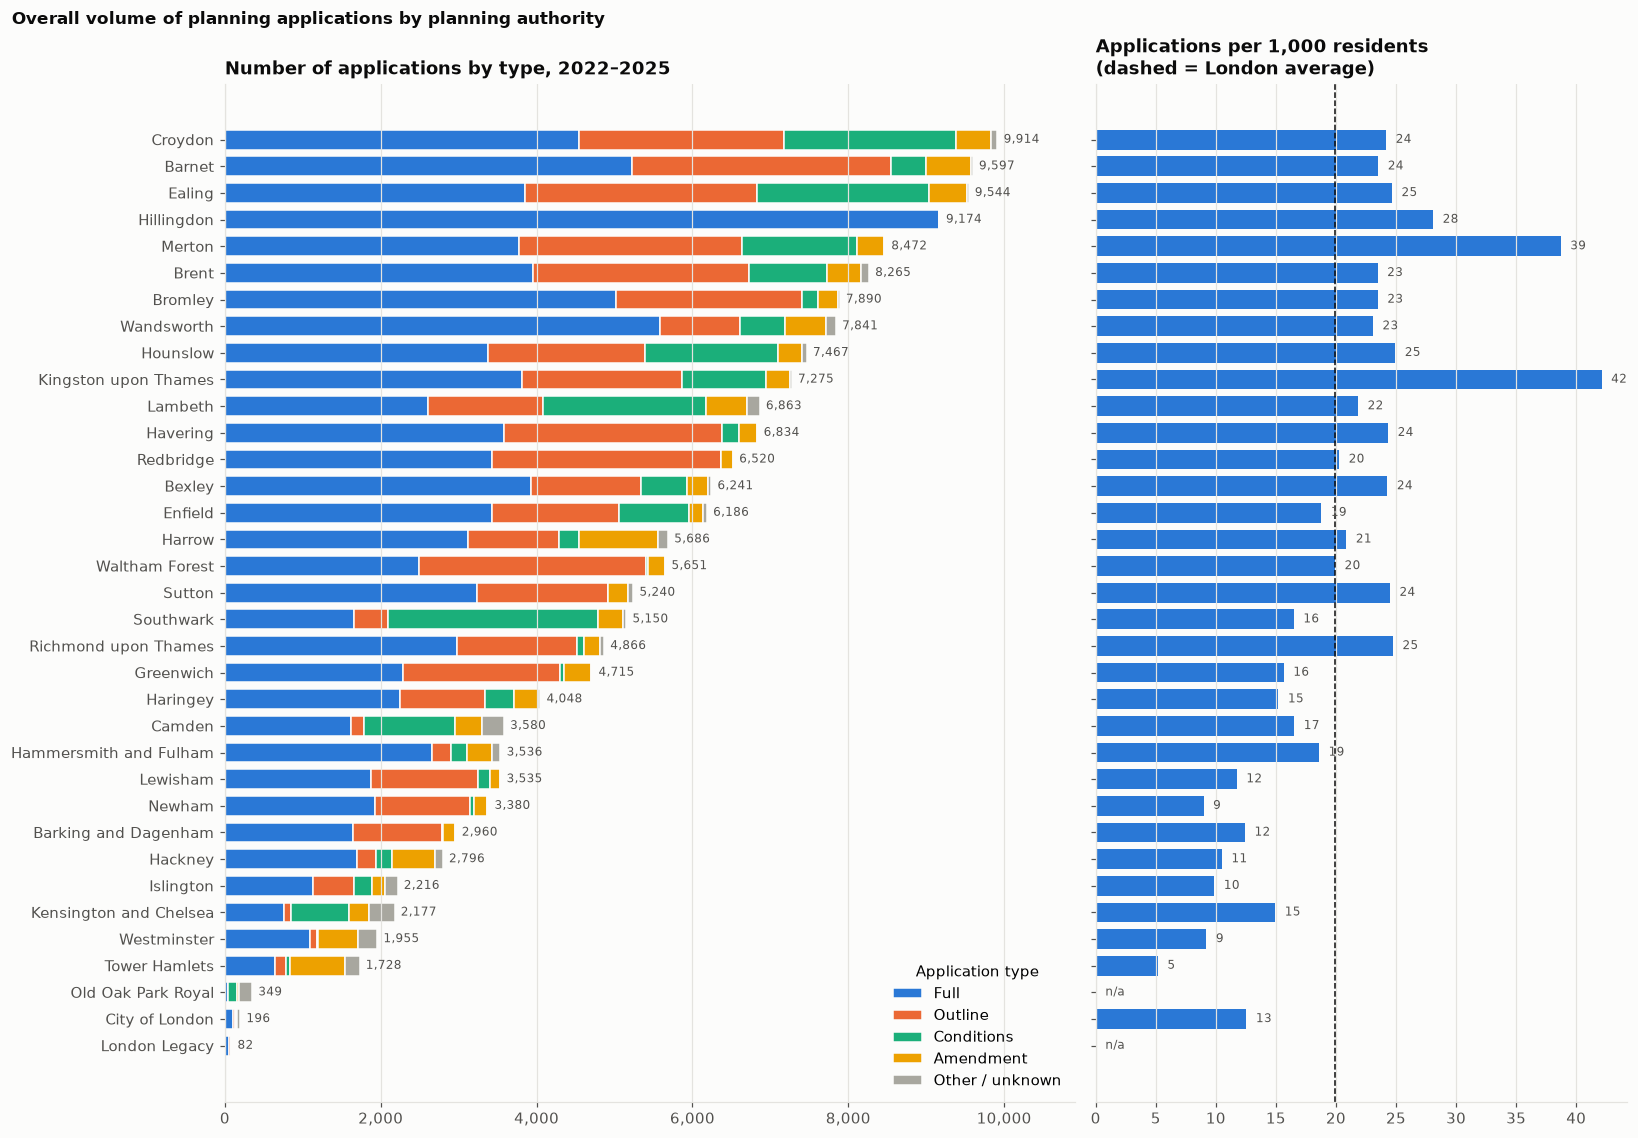

In [49]:
d = volume.sort_values("total")
fig, axes = plt.subplots(1, 2, figsize=(15, 10.5), sharey=True, gridspec_kw={"width_ratios": [1.6, 1]})
left = np.zeros(len(d))
for t in TYPE_ORDER:
    axes[0].barh(d.index, d[t], left=left, color=TYPE_COLORS[t], height=0.74, label=t, edgecolor="#fcfcfb", linewidth=1)
    left += d[t].values
for yi, v in enumerate(d["total"]):
    axes[0].text(v + 80, yi, f"{v:,}", va="center", fontsize=8, color=INK_2)
axes[0].xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
axes[0].set_xlim(0, d["total"].max() * 1.1)
axes[0].set_title("Number of applications by type, 2022–2025")
axes[0].legend(loc="lower right", title="Application type")
axes[0].grid(axis="y", visible=False)

per = d["per_1k_residents"]
axes[1].barh(d.index, per.fillna(0), color=APPROVED_C, height=0.74)
for yi, v in enumerate(per):
    axes[1].text((0 if np.isnan(v) else v) + 0.8, yi, "n/a" if np.isnan(v) else f"{v:.0f}", va="center",
                 fontsize=8, color=INK_2)
axes[1].axvline(volume["total"].sum() / pop["population"].sum() * 1000, color=INK, ls="--", lw=1)
axes[1].set_title("Applications per 1,000 residents\n(dashed = London average)")
axes[1].grid(axis="y", visible=False)
fig.suptitle("Overall volume of planning applications by planning authority", x=0.01, ha="left",
             fontweight="bold", color=INK)
plt.tight_layout()
plt.show()

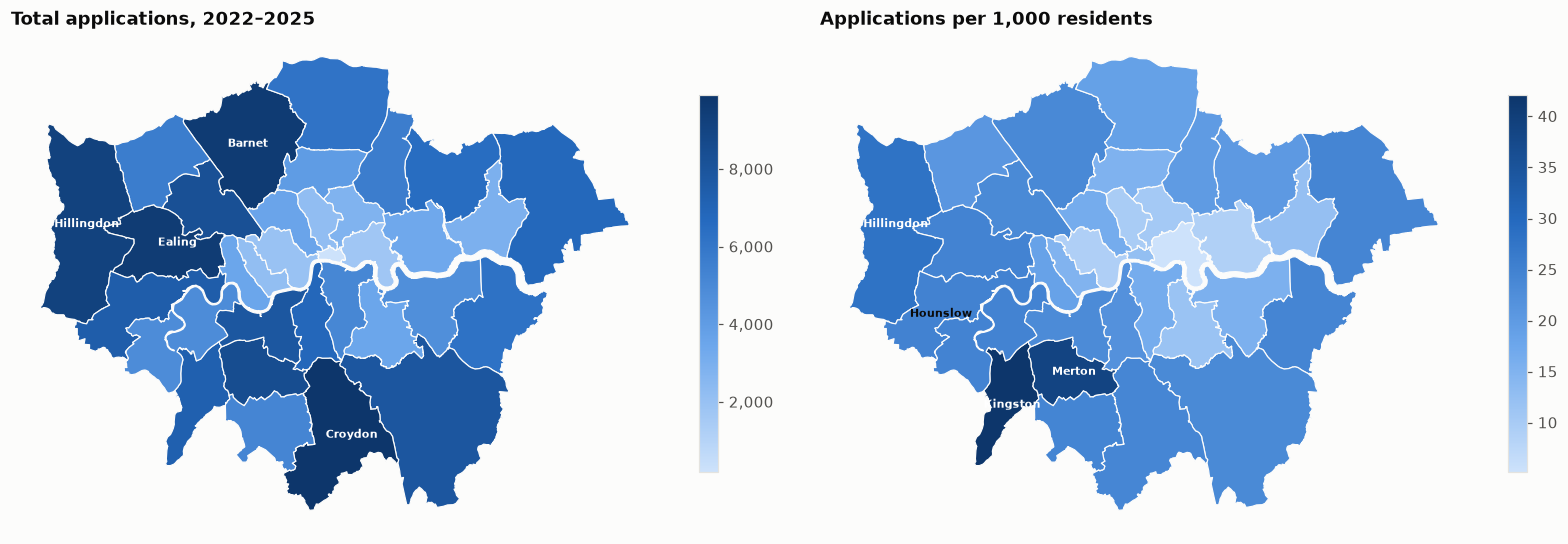

In [50]:
# Map: total volume and volume per resident (boroughs only; development corporations have no ONS boundary)
vmap = boroughs.merge(volume[["total", "per_1k_residents"]], left_on="borough", right_index=True, how="left")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, col_, title, fmt in [(axes[0], "total", "Total applications, 2022–2025", "{x:,.0f}"),
                             (axes[1], "per_1k_residents", "Applications per 1,000 residents", "{x:,.0f}")]:
    vmap.plot(column=col_, cmap=SEQUENTIAL, edgecolor="#fcfcfb", linewidth=0.8, ax=ax, legend=True,
              legend_kwds={"shrink": 0.6, "format": fmt})
    short = {v: k for k, v in NAME_FIX.items()}
    for _, r in vmap.nlargest(4, col_).iterrows():
        pt = r.geometry.representative_point()
        ax.annotate(short.get(r["borough"], r["borough"]), (pt.x, pt.y), ha="center", va="center", fontsize=7, fontweight="bold",
                    color="white" if r[col_] > 0.6 * vmap[col_].max() else INK)
    ax.set_title(title)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

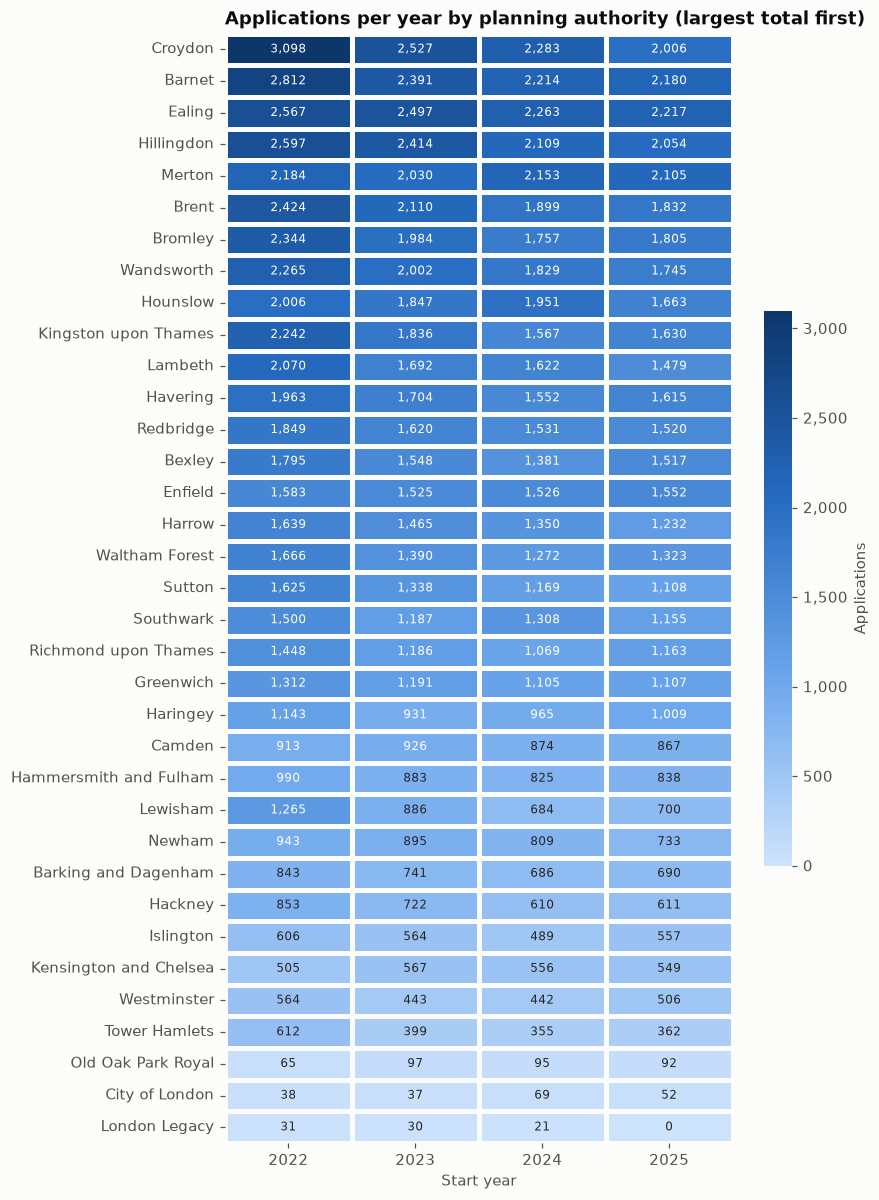

London-wide change 2022 → 2025: -20.6%
Biggest falls: Lewisham -45%, Tower Hamlets -41%, Croydon -35%
Biggest rises: Kensington and Chelsea +9%, Enfield -2%, Merton -4%
Highest volume: Croydon 9,914, Barnet 9,597, Ealing 9,544
Highest per 1,000 residents: Kingston upon Thames 42, Merton 39, Hillingdon 28
Lowest per 1,000 residents:  Tower Hamlets 5, Newham 9, Westminster 9


In [51]:
# Is volume stable over time? Applications per start year, per borough
yearly = pd.crosstab(vol["authority"], pd.to_datetime(vol["start_date"]).dt.year)
yearly = yearly.loc[volume.index]
fig, ax = plt.subplots(figsize=(8, 11))
sns.heatmap(yearly, cmap=SEQUENTIAL, annot=True, fmt=",", annot_kws={"size": 8}, linewidths=2,
            linecolor="#fcfcfb", cbar_kws={"shrink": 0.5, "label": "Applications", "format": "{x:,.0f}"}, ax=ax)
ax.set_xlabel("Start year")
ax.set_ylabel("")
ax.grid(False)
ax.set_title("Applications per year by planning authority (largest total first)")
plt.tight_layout()
plt.show()

change = (yearly[2025] / yearly[2022] - 1).drop(["Old Oak Park Royal", "London Legacy", "City of London"], errors="ignore")
print(f"London-wide change 2022 → 2025: {yearly[2025].sum() / yearly[2022].sum() - 1:+.1%}")
print("Biggest falls:", ", ".join(f"{b} {v:+.0%}" for b, v in change.nsmallest(3).items()))
print("Biggest rises:", ", ".join(f"{b} {v:+.0%}" for b, v in change.nlargest(3).items()))
print("Highest volume:", ", ".join(f"{b} {v:,}" for b, v in volume["total"].head(3).items()))
print("Highest per 1,000 residents:", ", ".join(f"{b} {v:.0f}" for b, v in volume["per_1k_residents"].nlargest(3).items()))
print("Lowest per 1,000 residents: ", ", ".join(f"{b} {v:.0f}" for b, v in volume["per_1k_residents"].nsmallest(3).items()))